In [1]:
import pandas as pd
import seaborn as sns
import shap
import matplotlib.pyplot as plt
import statsmodels.api as smi
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.simplefilter('ignore')

In [2]:
df = pd.read_csv(r'/content/Thyroid_Diff.csv')
df.head(5)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [4]:
label_encoder = LabelEncoder()
for column in df.columns:
  df[column] = label_encoder.fit_transform(df[column])
df.head(1)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,11,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0


In [5]:
df.describe()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000
mean,24.819843,0.185379,0.127937,0.073107,0.018277,1.950392,2.561358,2.924282,2.550914,0.644909,1.566580,2.206266,0.543081,0.046997,0.242820,1.574413,0.281984
std,15.005982,0.389113,0.334457,0.260653,0.134126,0.630917,1.350110,1.172106,0.890257,0.479167,0.643233,1.344667,0.857732,0.211910,0.773274,0.917585,0.450554
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,3.000000,2.500000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,21.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,3.000000,3.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,35.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,3.000000,3.000000,1.000000,2.000000,3.000000,1.000000,0.000000,0.000000,2.000000,1.000000
max,64.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000,5.000000,3.000000,1.000000,2.000000,6.000000,2.000000,1.000000,4.000000,3.000000,1.000000


In [6]:
df.mean()

,0
Age,24.819843
Gender,0.185379
Smoking,0.127937
Hx Smoking,0.073107
Hx Radiothreapy,0.018277
Thyroid Function,1.950392
Physical Examination,2.561358
Adenopathy,2.924282
Pathology,2.550914
Focality,0.644909


In [7]:
df.median()

,0
Age,21.0
Gender,0.0
Smoking,0.0
Hx Smoking,0.0
Hx Radiothreapy,0.0
Thyroid Function,2.0
Physical Examination,3.0
Adenopathy,3.0
Pathology,3.0
Focality,1.0


In [8]:
df.skew()

,0
Age,0.686464
Gender,1.625611
Smoking,2.236555
Hx Smoking,3.292764
Hx Radiothreapy,7.220870
Thyroid Function,-0.338695
Physical Examination,-0.243145
Adenopathy,-0.705364
Pathology,-1.944692
Focality,-0.608011


In [9]:
df.isnull().sum()

,0
Age,0
Gender,0
Smoking,0
Hx Smoking,0
Hx Radiothreapy,0
Thyroid Function,0
Physical Examination,0
Adenopathy,0
Pathology,0
Focality,0


In [10]:
df.shape

(383, 17)

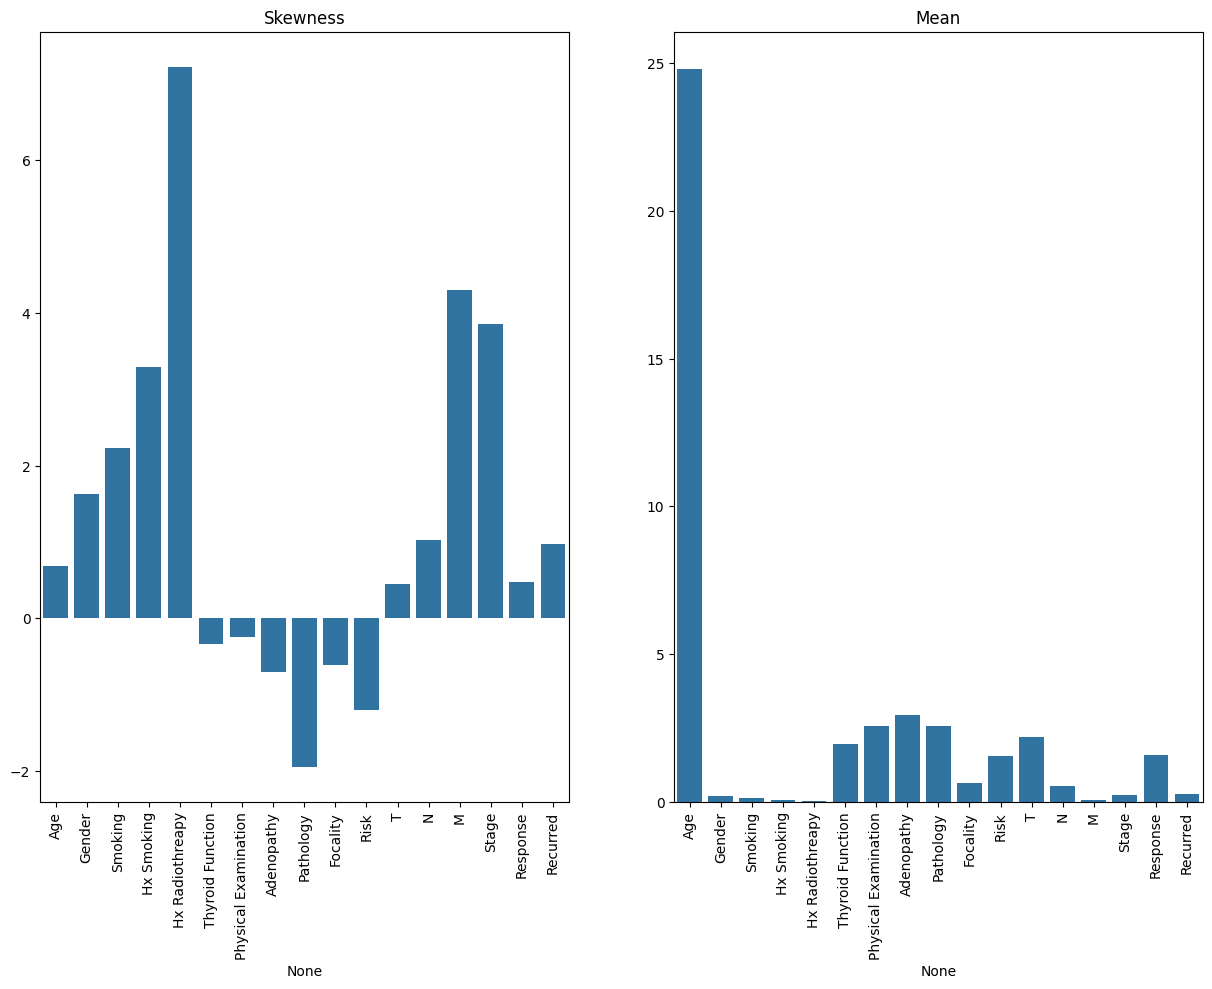

In [11]:
skewness_values = df.skew()
mean_values = df.mean()
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
sns.barplot(x=skewness_values.index, y=skewness_values.values, ax=ax[0])
ax[0].set_title('Skewness')
ax[0].tick_params(axis='x', rotation=90)
sns.barplot(x=mean_values.index, y=mean_values.values, ax=ax[1])
ax[1].set_title('Mean')
ax[1].tick_params(axis='x', rotation=90)
plt.show()

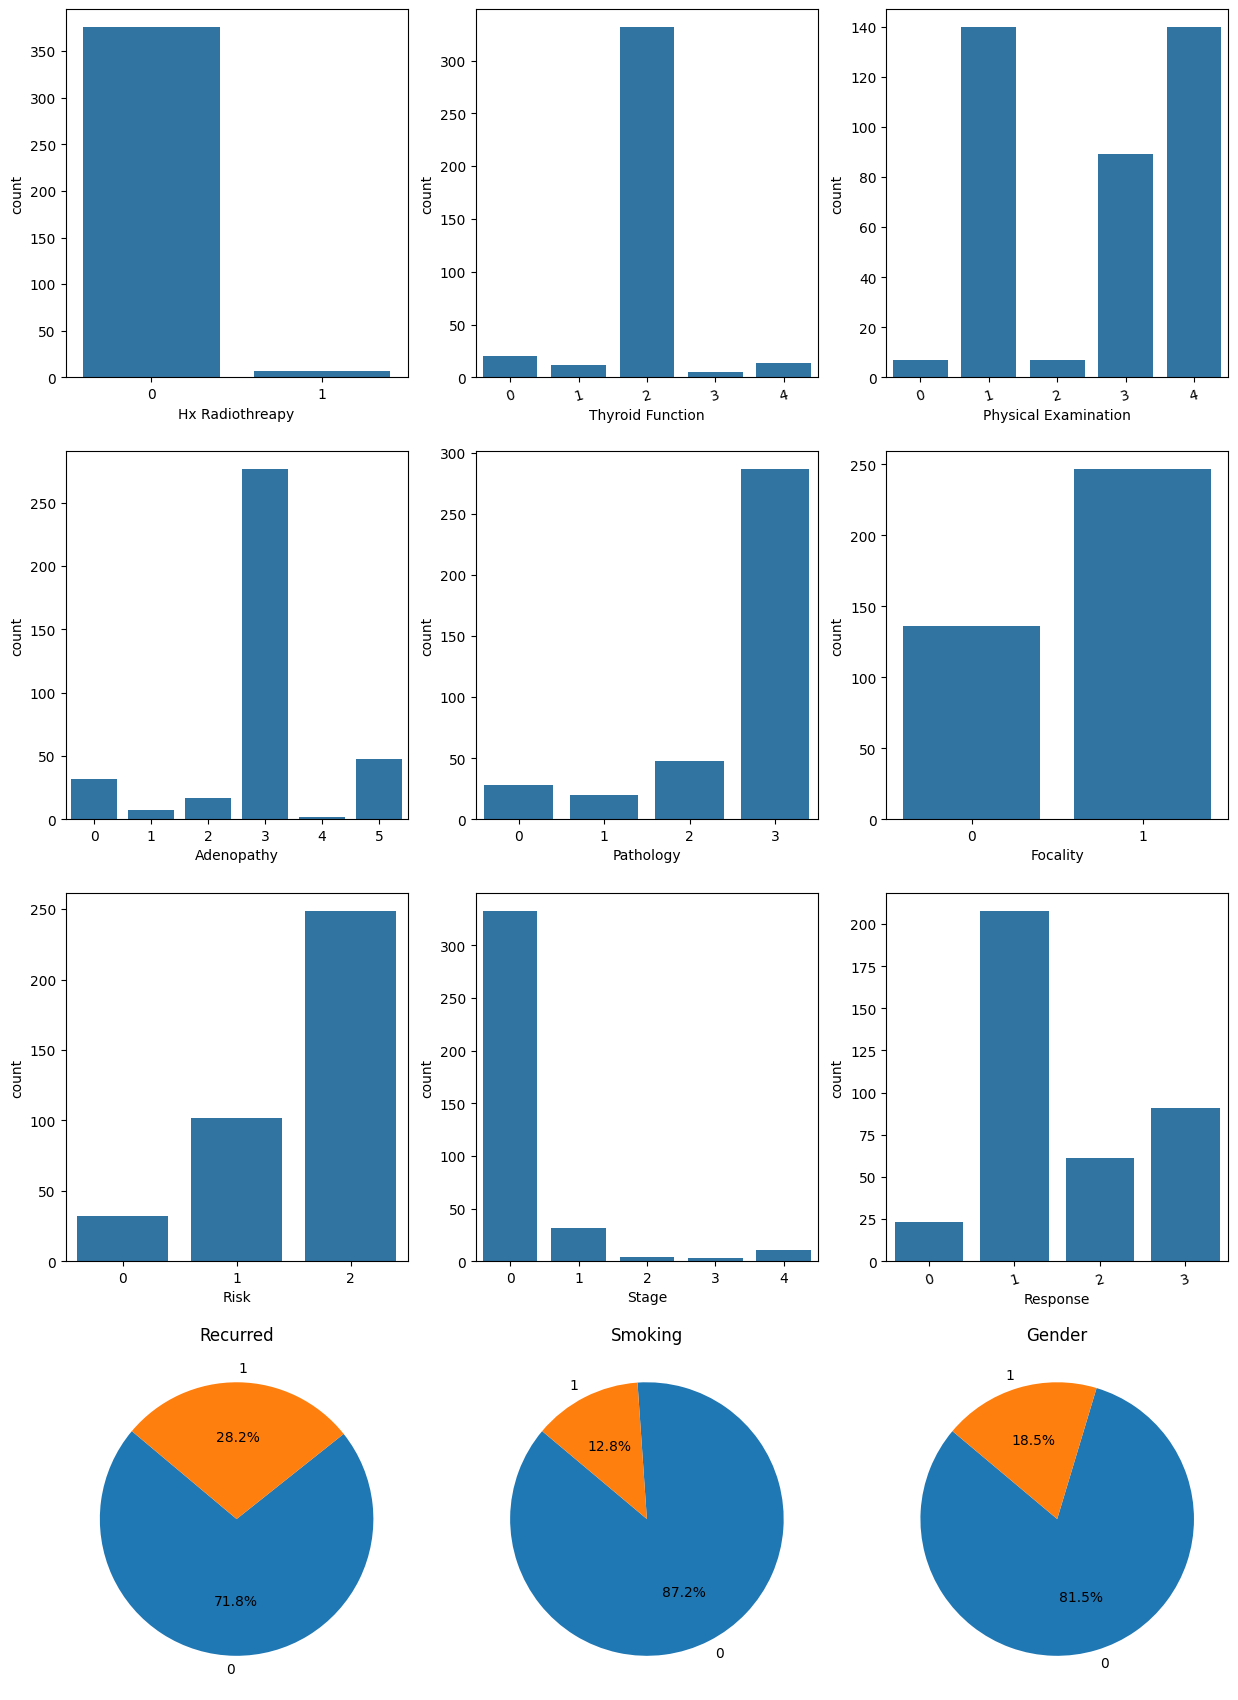

In [12]:
fig, ax = plt.subplots(4, 3, figsize=(15, 22))
sns.countplot(data=df, x='Hx Radiothreapy', ax=ax[0, 0])
sns.countplot(data=df, x='Thyroid Function', ax=ax[0, 1])
sns.countplot(data=df, x='Physical Examination', ax=ax[0, 2])
sns.countplot(data=df, x='Adenopathy', ax=ax[1, 0])
sns.countplot(data=df, x='Pathology', ax=ax[1, 1])
sns.countplot(data=df, x='Focality', ax=ax[1, 2])
sns.countplot(data=df, x='Risk', ax=ax[2, 0])
sns.countplot(data=df, x='Stage', ax=ax[2, 1])
sns.countplot(data=df, x='Response', ax=ax[2, 2])
ax[3, 0].pie(df['Recurred'].value_counts(), labels=df['Recurred'].value_counts().index, autopct='%1.1f%%', startangle=140)
ax[3, 0].set_title('Recurred')
ax[3, 1].pie(df['Smoking'].value_counts(), labels=df['Smoking'].value_counts().index, autopct='%1.1f%%', startangle=140)
ax[3, 1].set_title('Smoking')
ax[3, 2].pie(df['Gender'].value_counts(), labels=df['Gender'].value_counts().index, autopct='%1.1f%%', startangle=140)
ax[3, 2].set_title('Gender')
ax[0, 1].tick_params(axis='x', labelrotation=15)
ax[0, 2].tick_params(axis='x', labelrotation=15)
ax[2, 2].tick_params(axis='x', labelrotation=15)
plt.show()

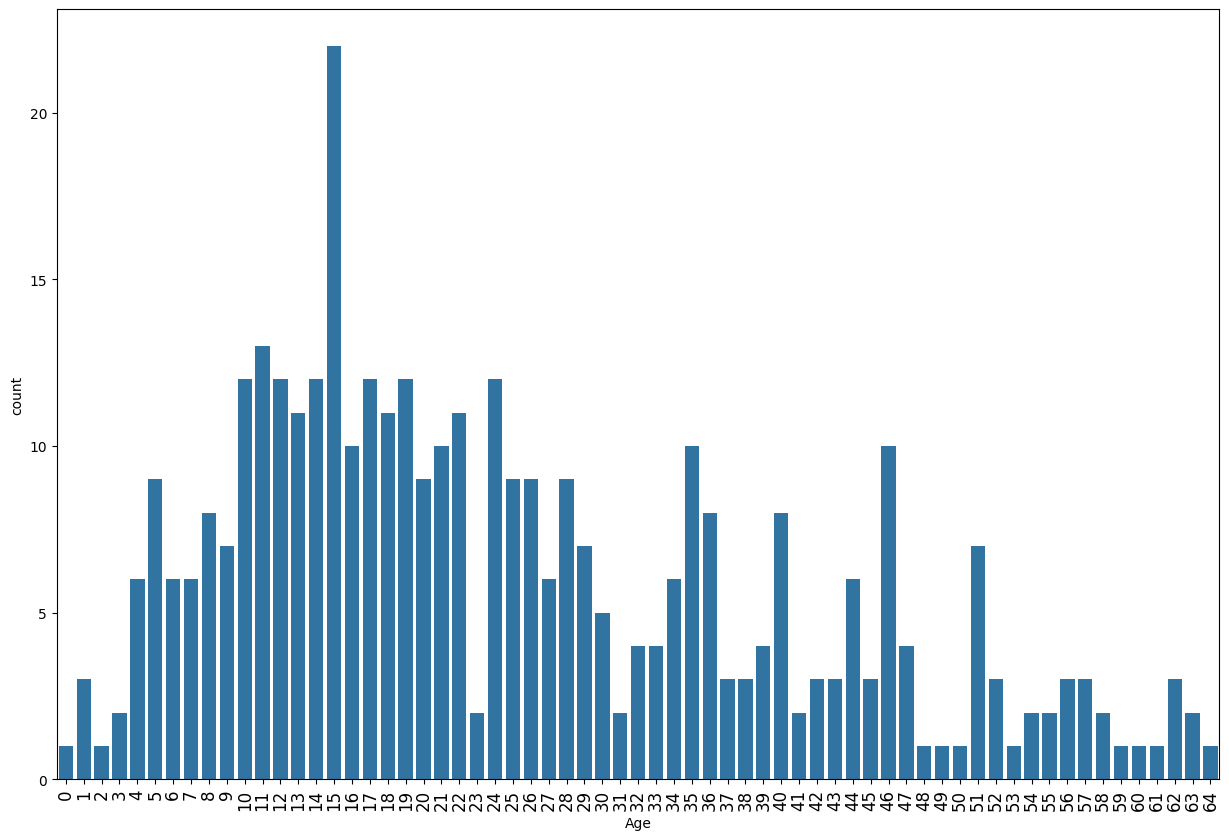

In [13]:
plt.figure(figsize=(15,10))
sns.countplot(data = df , x = 'Age')
plt.xticks(rotation=90, fontsize = 12)
plt.show()

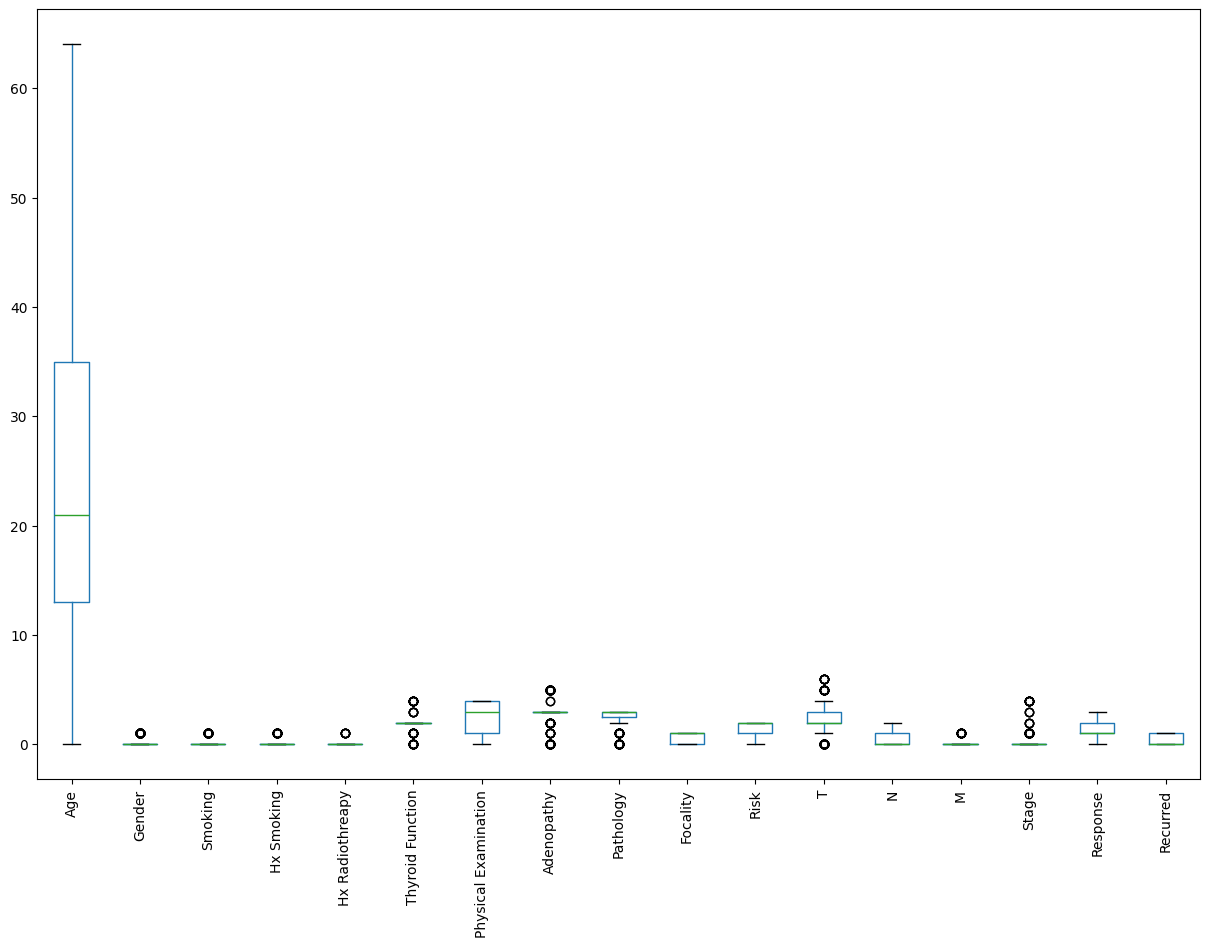

In [14]:
plt.figure(figsize=(15, 10))
ax = df.boxplot(figsize=(15, 10), grid=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

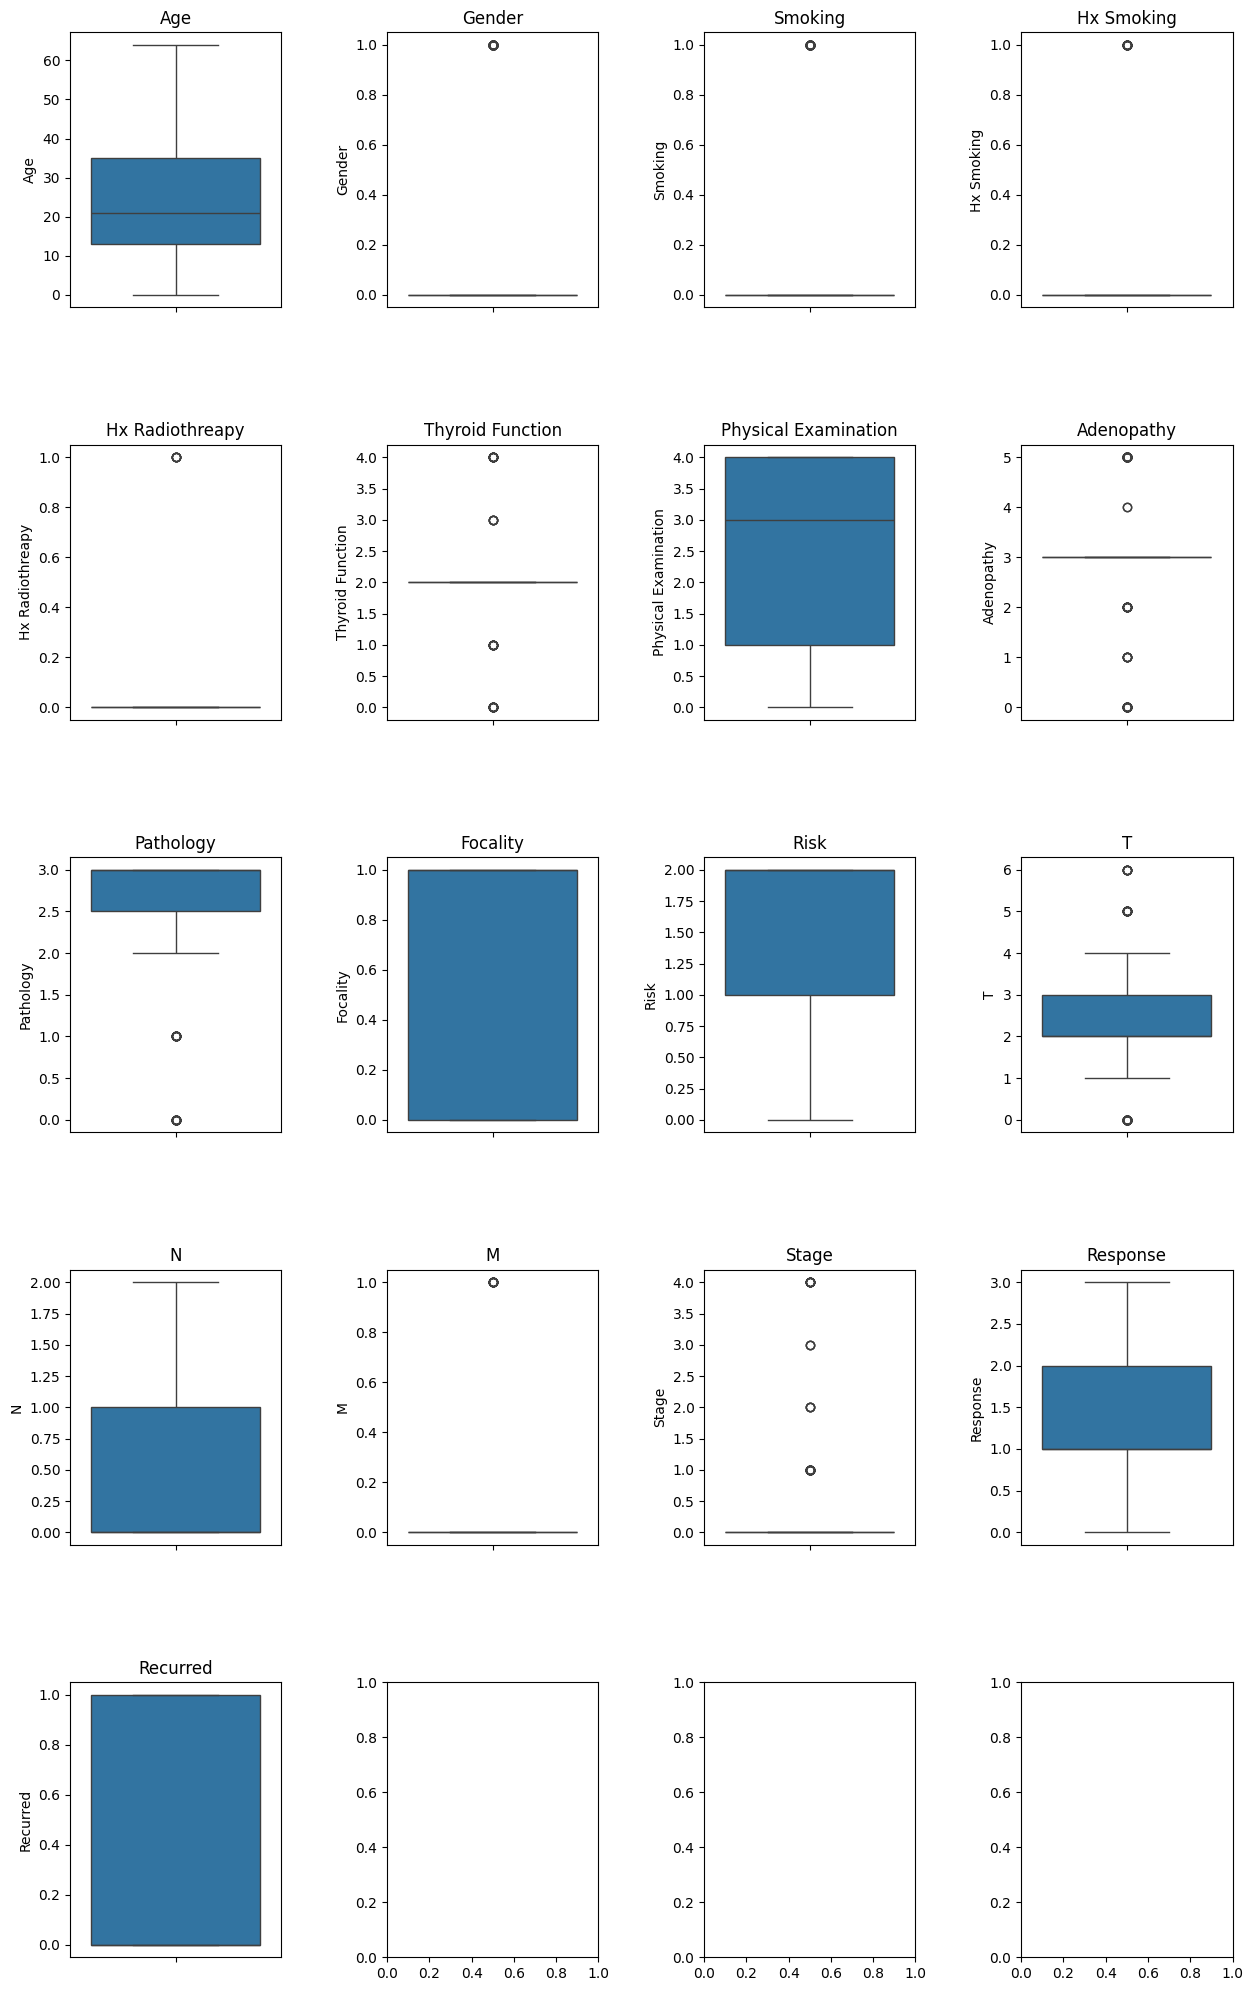

In [15]:
columnas_por_fila = 4
num_columnas = len(df.describe().columns)
num_filas = -(-num_columnas // columnas_por_fila)
fig, ax = plt.subplots(num_filas, columnas_por_fila, figsize=(15, 25))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
for i, columna in enumerate(df.describe().columns):
  fila_actual = i // columnas_por_fila
  columna_actual = i % columnas_por_fila
  sns.boxplot(df[columna], ax=ax[fila_actual, columna_actual])
  ax[fila_actual, columna_actual].set_title(columna)
plt.show()

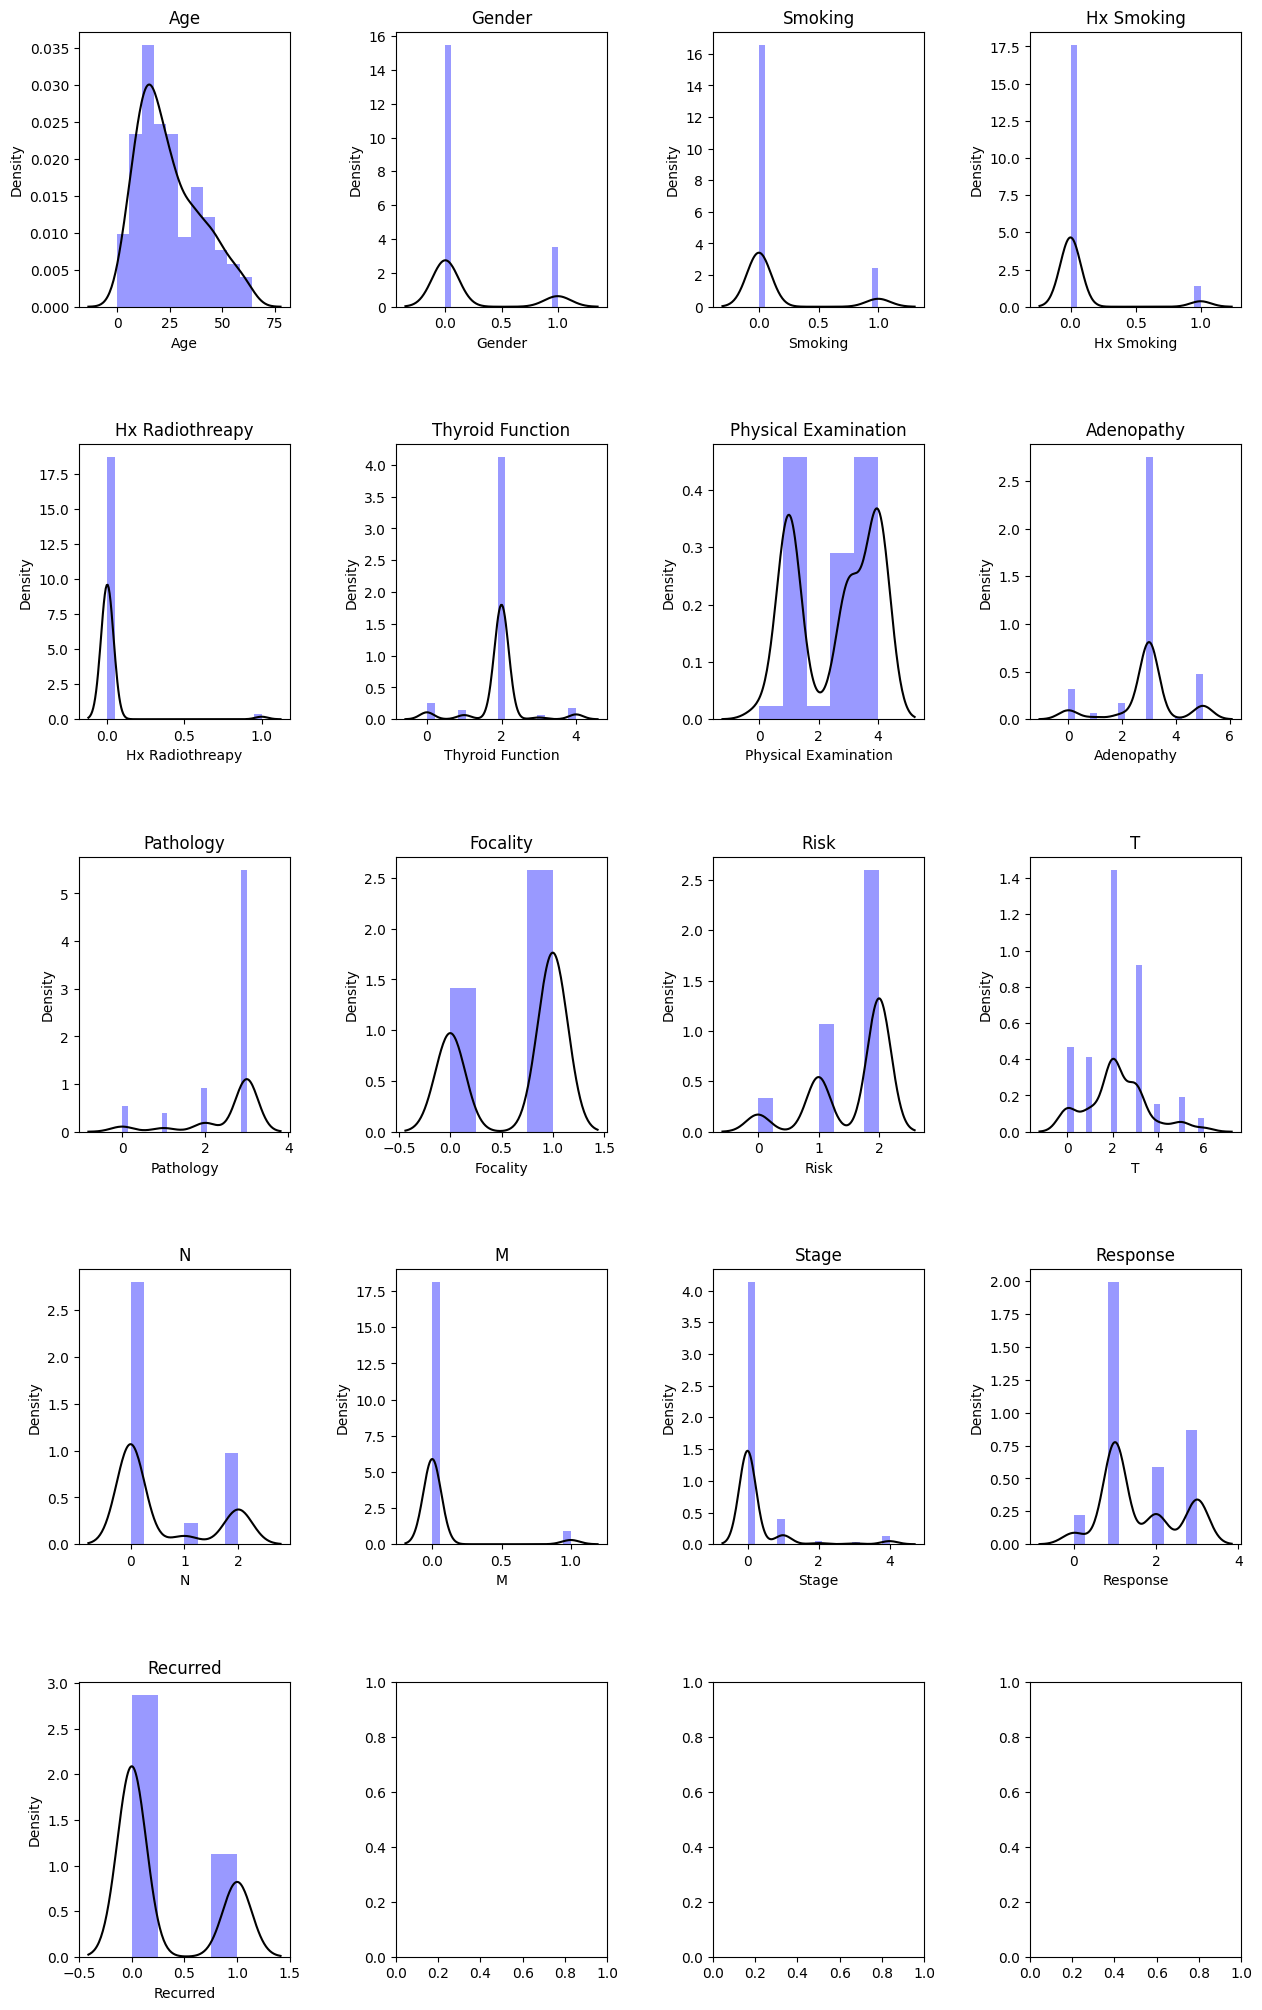

In [16]:
columnas_por_fila = 4
num_columnas = len(df.describe().columns)
num_filas = -(-num_columnas // columnas_por_fila)
fig, ax = plt.subplots(num_filas, columnas_por_fila, figsize=(15, 25))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
for i, columna in enumerate(df.describe().columns):
  fila_actual = i // columnas_por_fila
  columna_actual = i % columnas_por_fila
  sns.distplot(df[columna], ax=ax[fila_actual, columna_actual],color='black', hist_kws={'color': 'blue'})
  ax[fila_actual, columna_actual].set_title(columna)
plt.show()

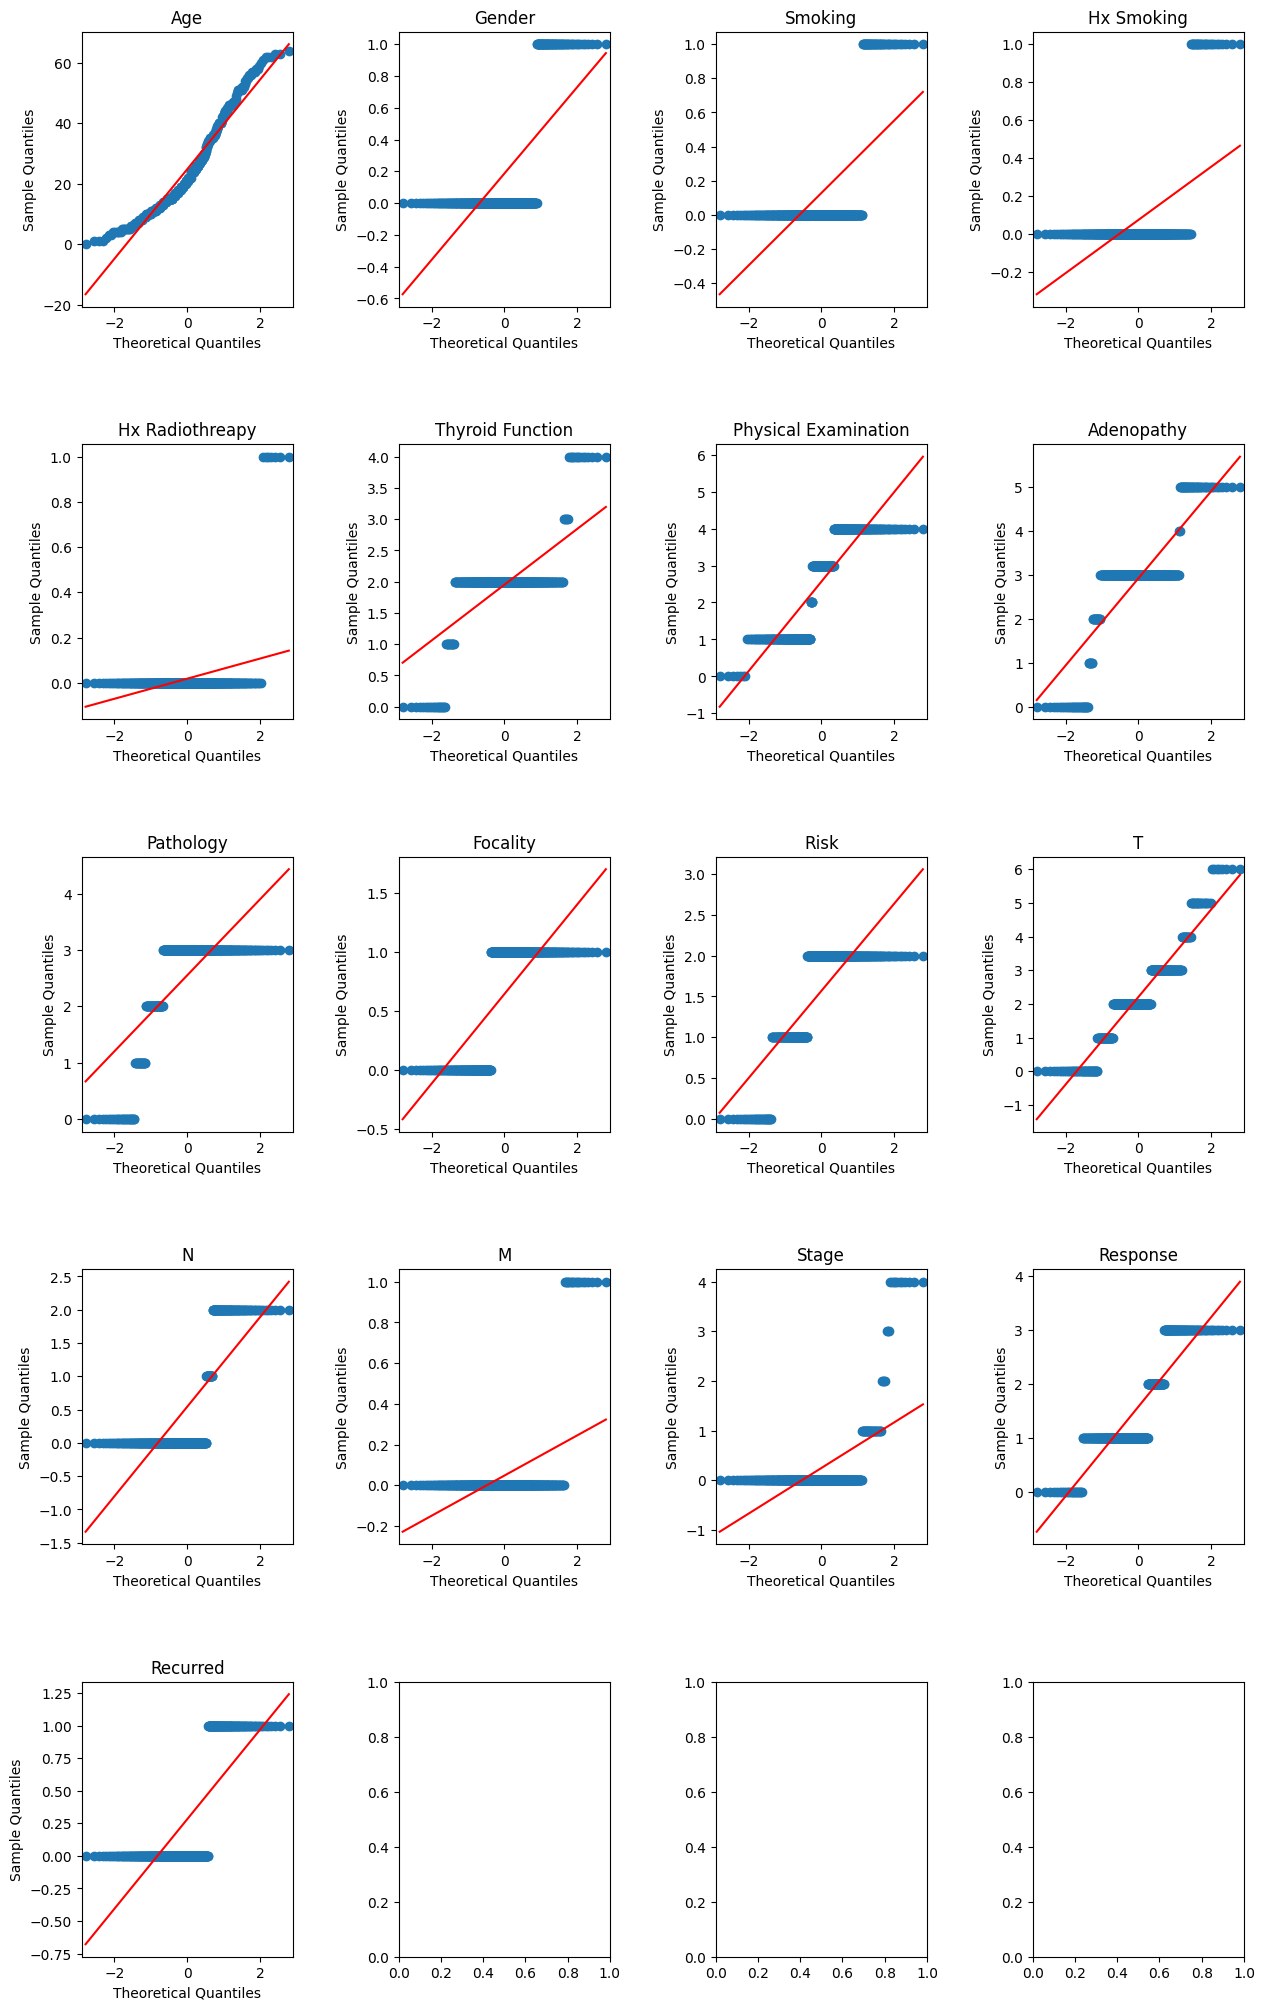

In [17]:
columnas_por_fila = 4
num_columnas = len(df.describe().columns)
num_filas = -(-num_columnas // columnas_por_fila)
fig, ax = plt.subplots(num_filas, columnas_por_fila, figsize=(15, 25))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
for i, columna in enumerate(df.describe().columns):
  fila_actual = i // columnas_por_fila
  columna_actual = i % columnas_por_fila
  smi.qqplot(df[columna], ax=ax[fila_actual, columna_actual],line="r")
  ax[fila_actual, columna_actual].set_title(columna)
plt.show()

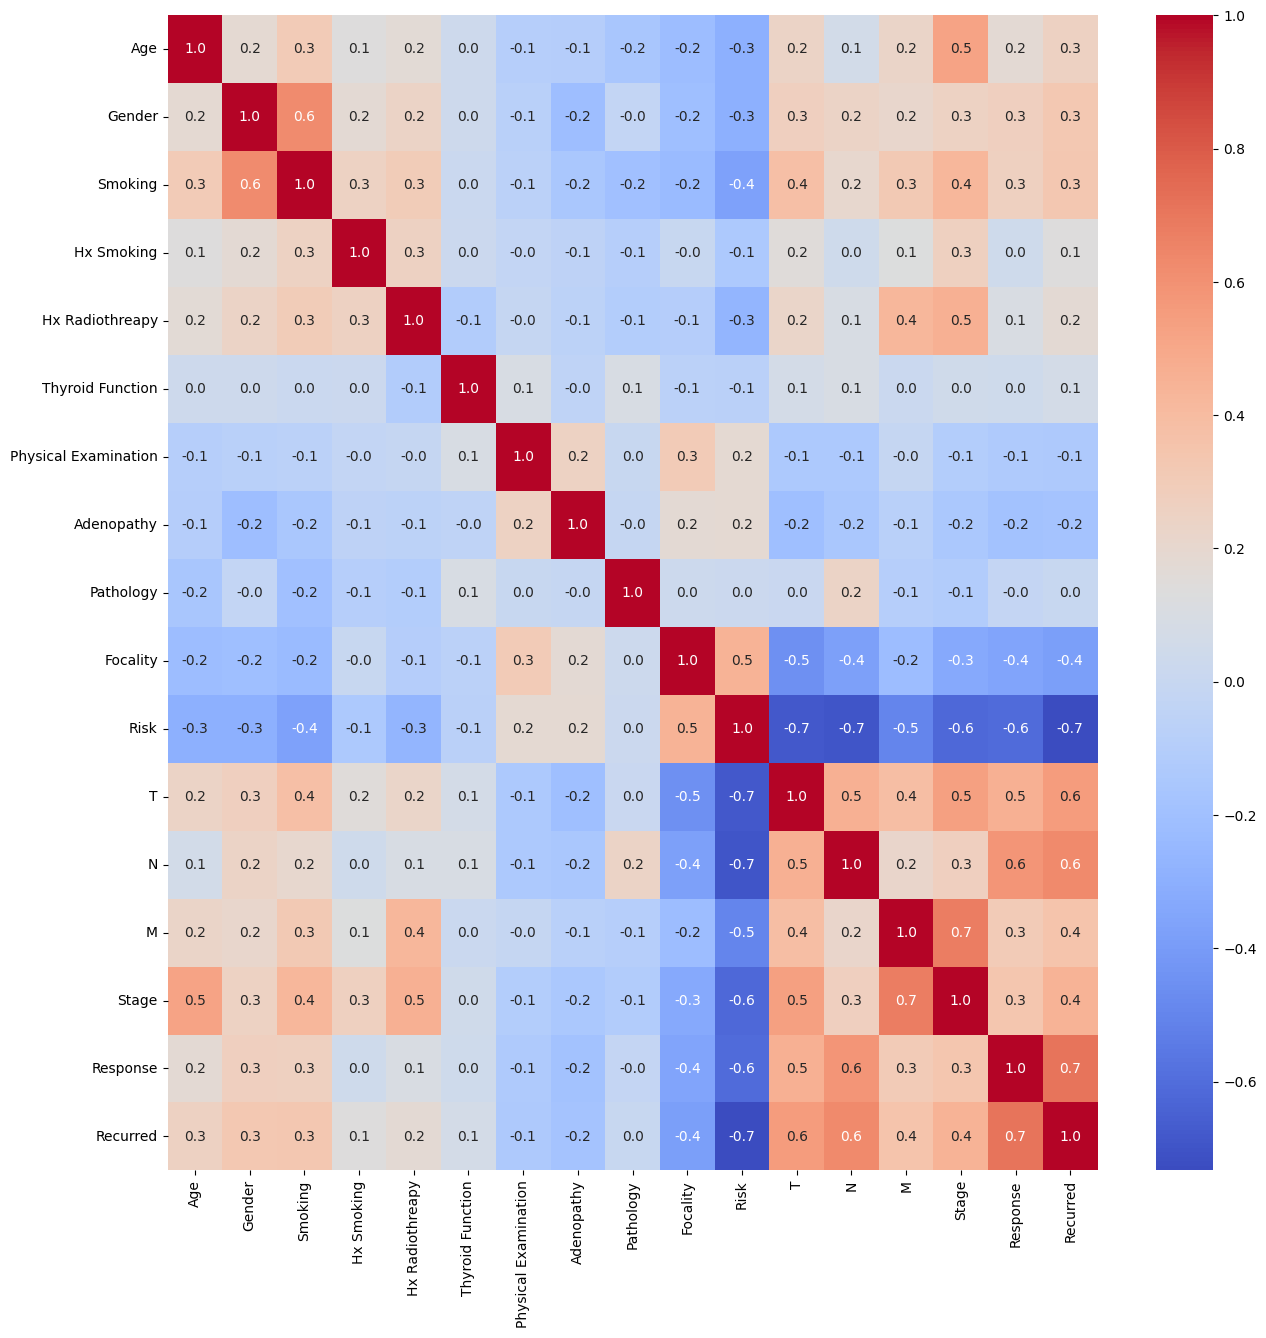

In [18]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot = True, fmt = '.1f', cmap='coolwarm')
plt.show()

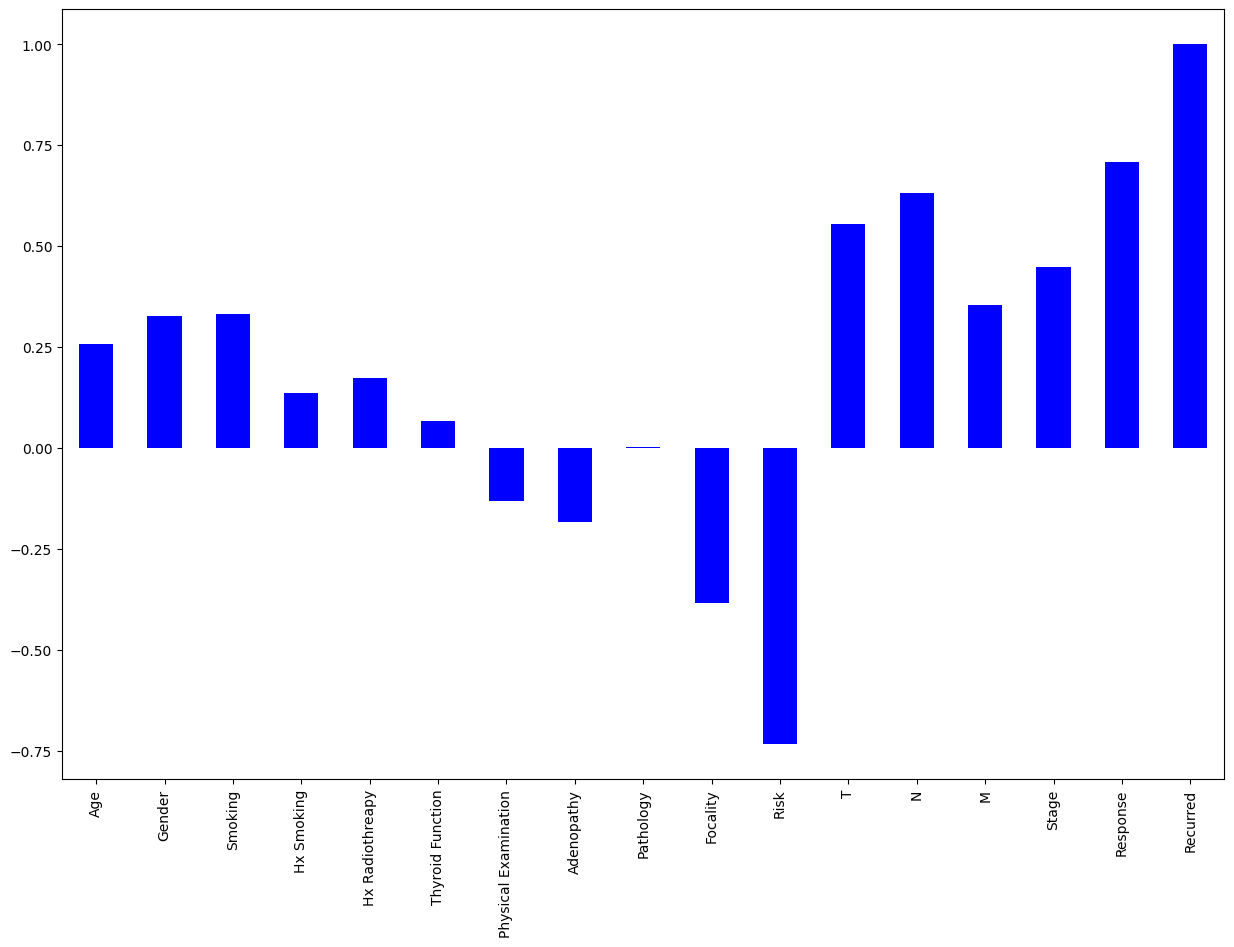

In [19]:
correlation_matrix = df.corr()
correlation_matrix['Recurred'].plot(kind='bar', color='blue', figsize =(15,10))
plt.show()

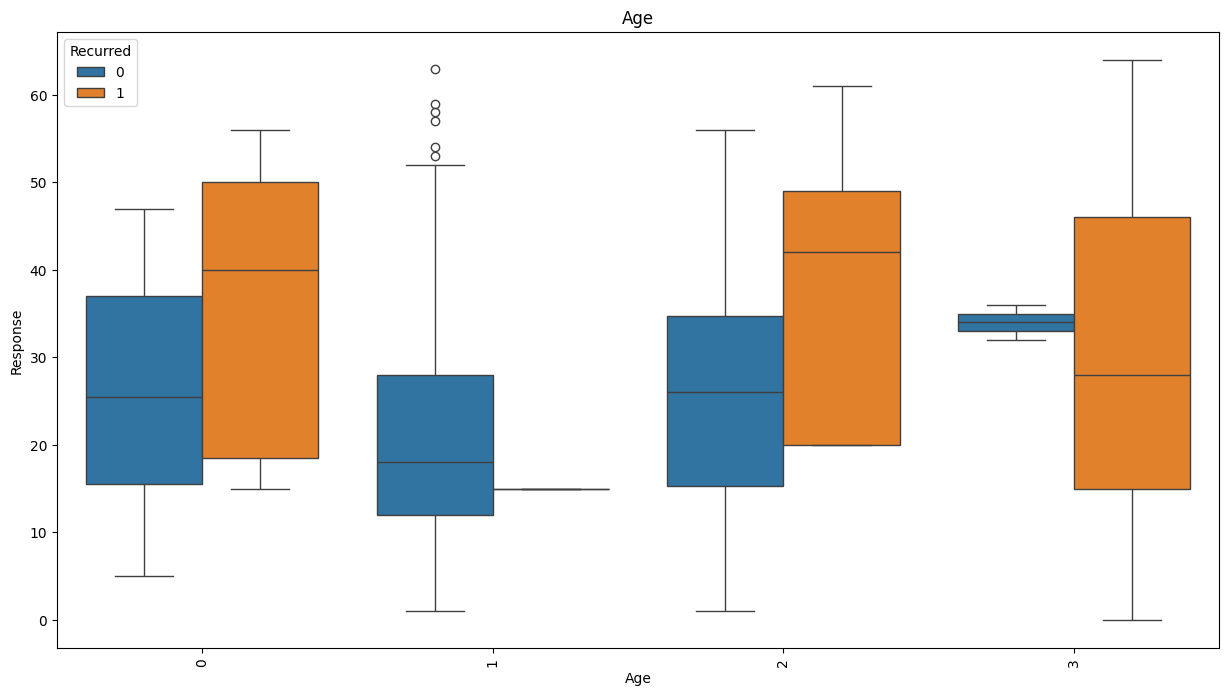

In [20]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, x='Response', y='Age', hue ='Recurred')
plt.title('Age')
plt.xlabel('Age')
plt.ylabel('Response')
plt.xticks(rotation=90)
plt.show()

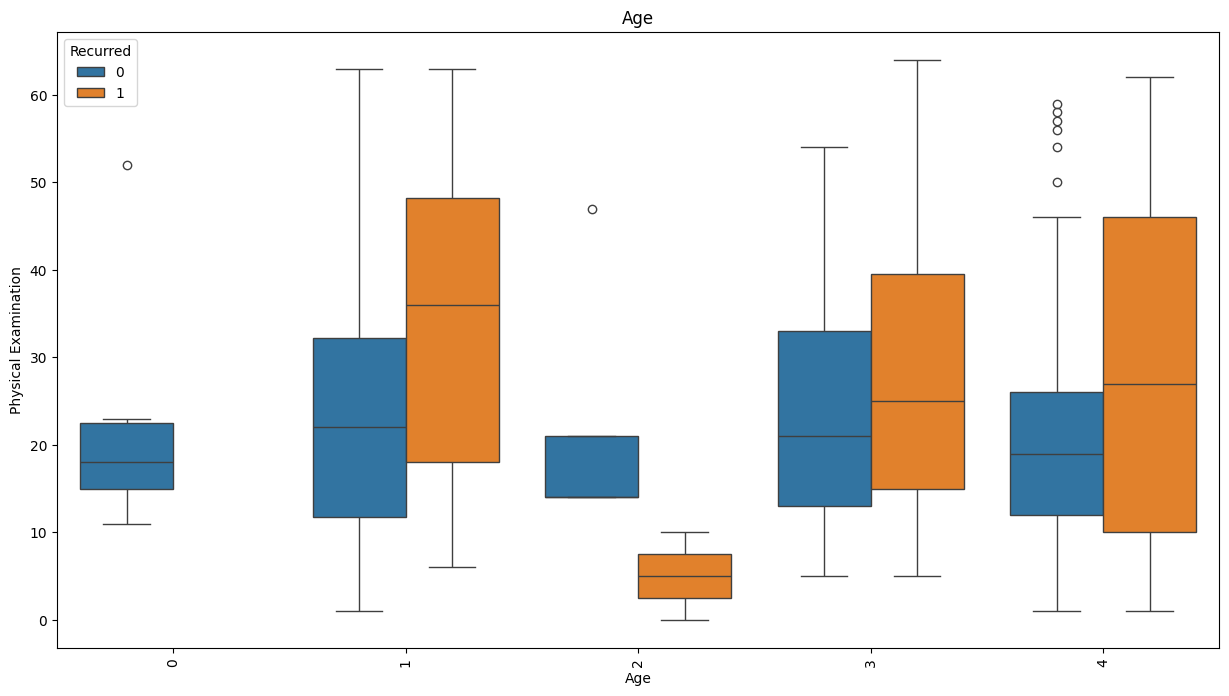

In [21]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, x='Physical Examination', y='Age', hue ='Recurred')
plt.title('Age')
plt.xlabel('Age')
plt.ylabel('Physical Examination')
plt.xticks(rotation=90)
plt.show()

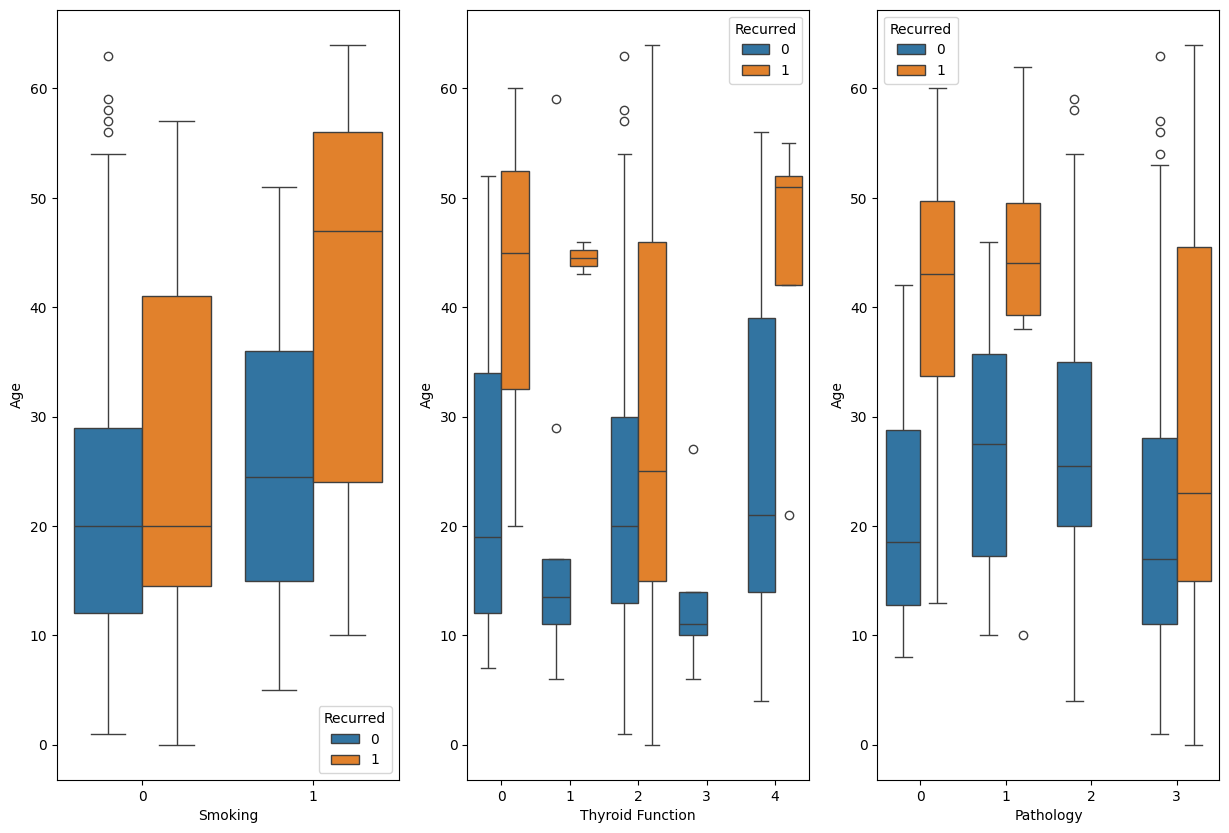

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(15, 10))
sns.boxplot(data=df, x='Smoking', y='Age', hue='Recurred',ax = ax[0])
sns.boxplot(data=df, x='Thyroid Function', y='Age', hue='Recurred',ax = ax[1])
sns.boxplot(data=df, x='Pathology', y='Age', hue='Recurred',ax = ax[2])
plt.show()

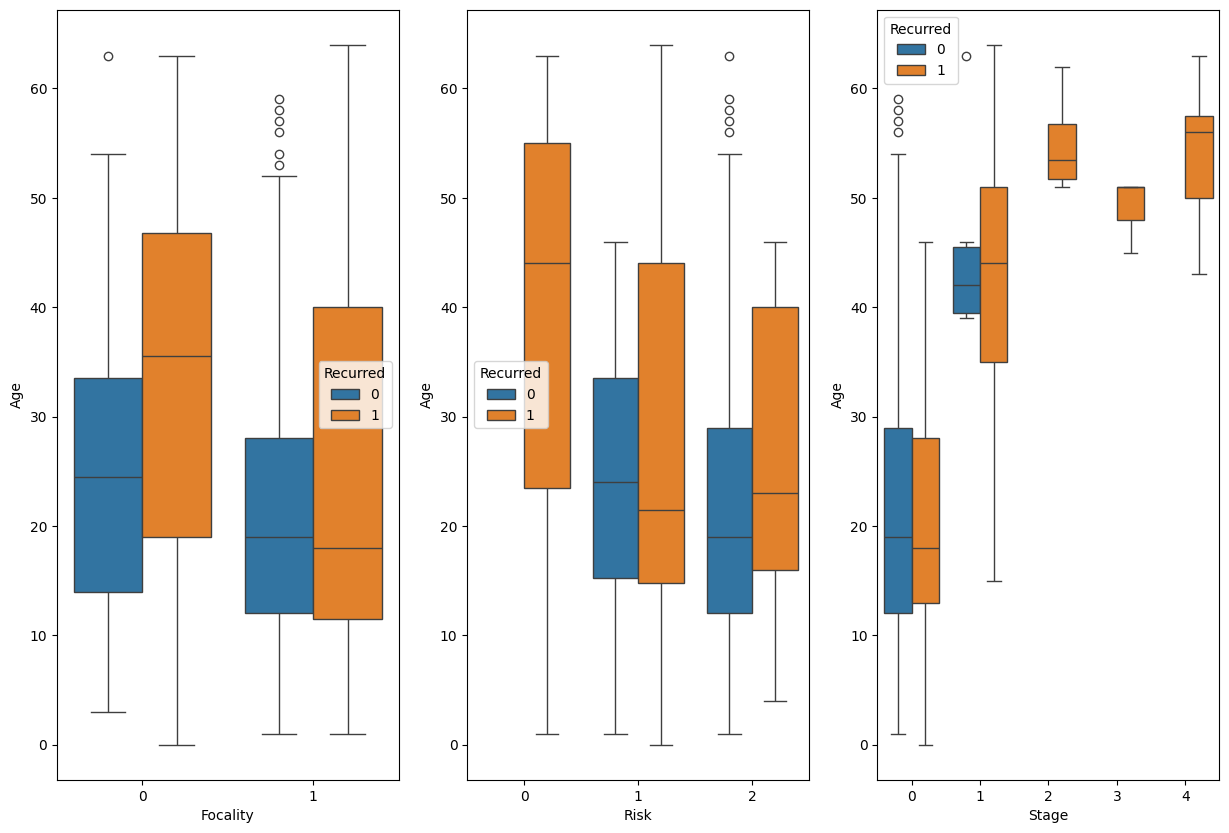

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15, 10))
sns.boxplot(data=df, x='Focality', y='Age', hue='Recurred',ax = ax[0])
sns.boxplot(data=df, x='Risk', y='Age', hue='Recurred',ax = ax[1])
sns.boxplot(data=df, x='Stage', y='Age', hue='Recurred',ax = ax[2])
plt.show()

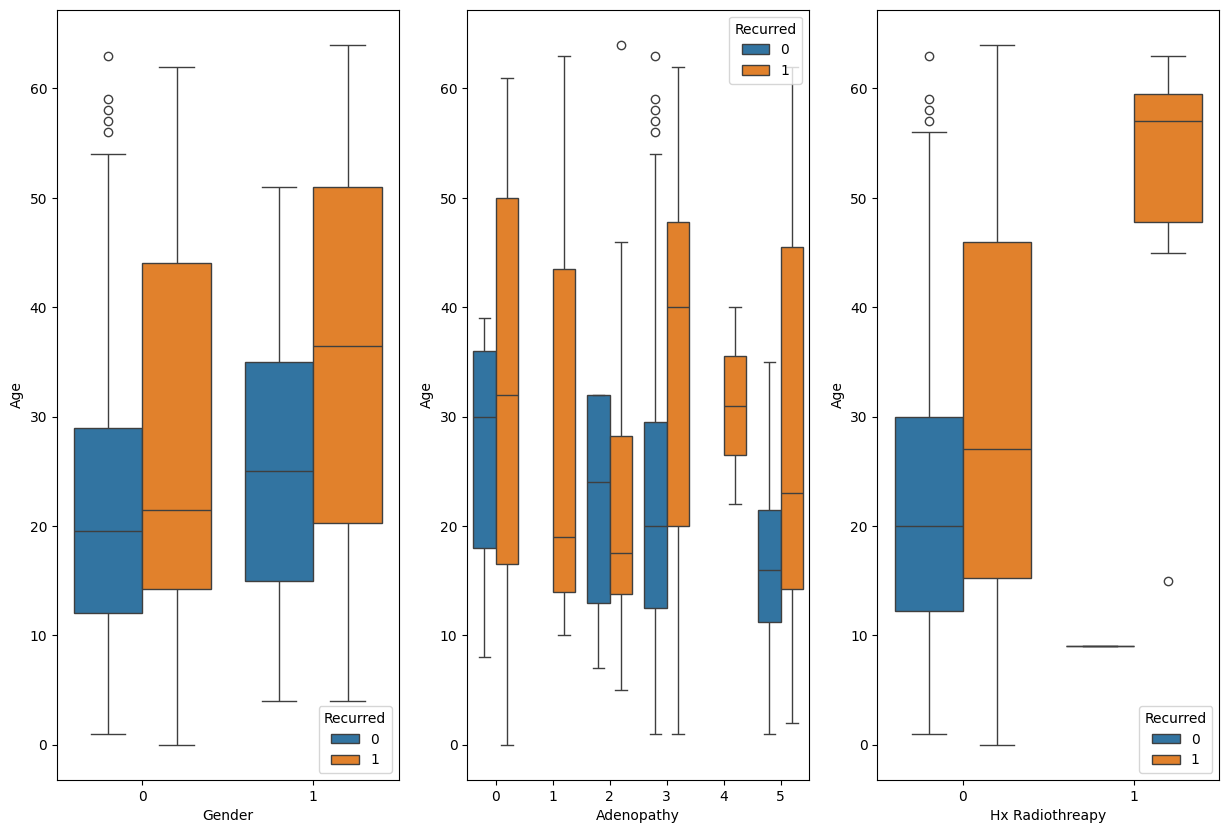

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 10))
sns.boxplot(data=df, x='Gender', y='Age', hue='Recurred',ax = ax[0])
sns.boxplot(data=df, x='Adenopathy', y='Age', hue='Recurred',ax = ax[1])
sns.boxplot(data=df, x='Hx Radiothreapy', y='Age', hue='Recurred',ax = ax[2])
plt.show()

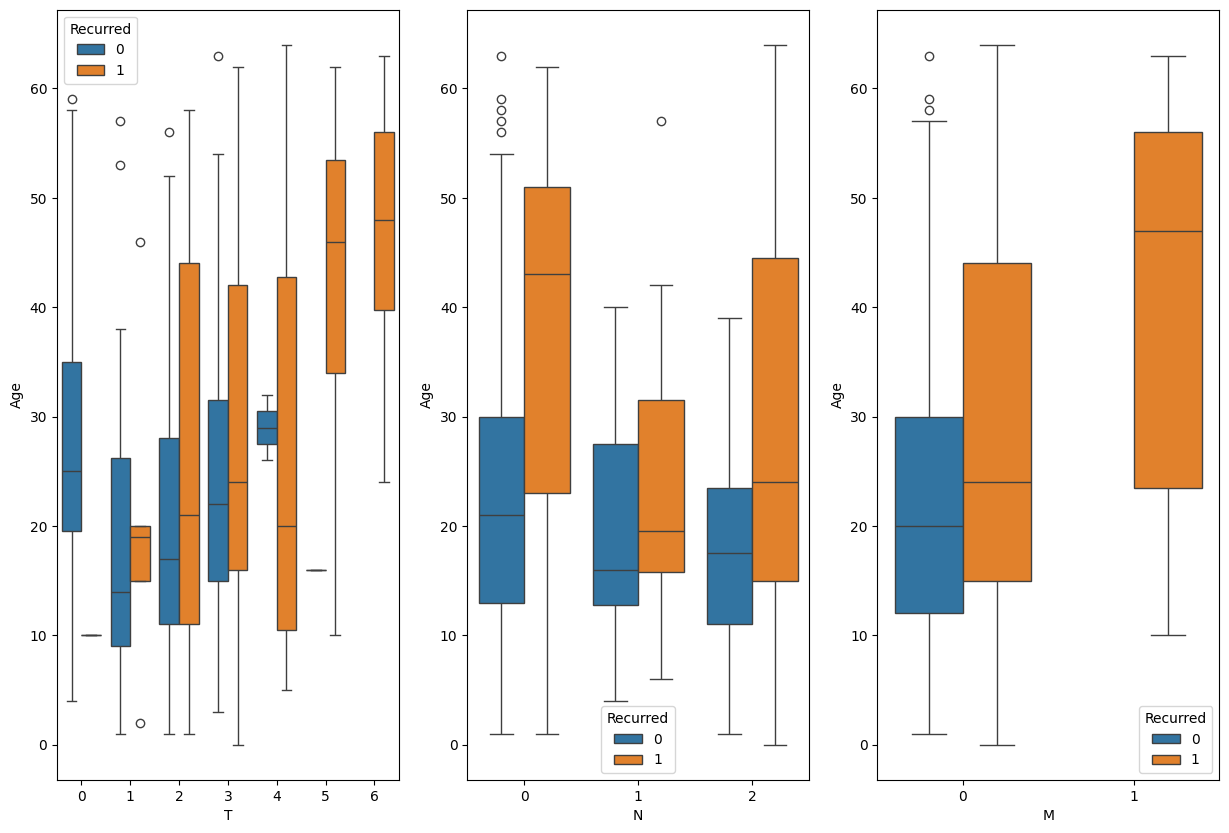

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(15, 10))
sns.boxplot(data=df, x='T', y='Age', hue='Recurred',ax = ax[0])
sns.boxplot(data=df, x='N', y='Age', hue='Recurred',ax = ax[1])
sns.boxplot(data=df, x='M', y='Age', hue='Recurred',ax = ax[2])
plt.show()

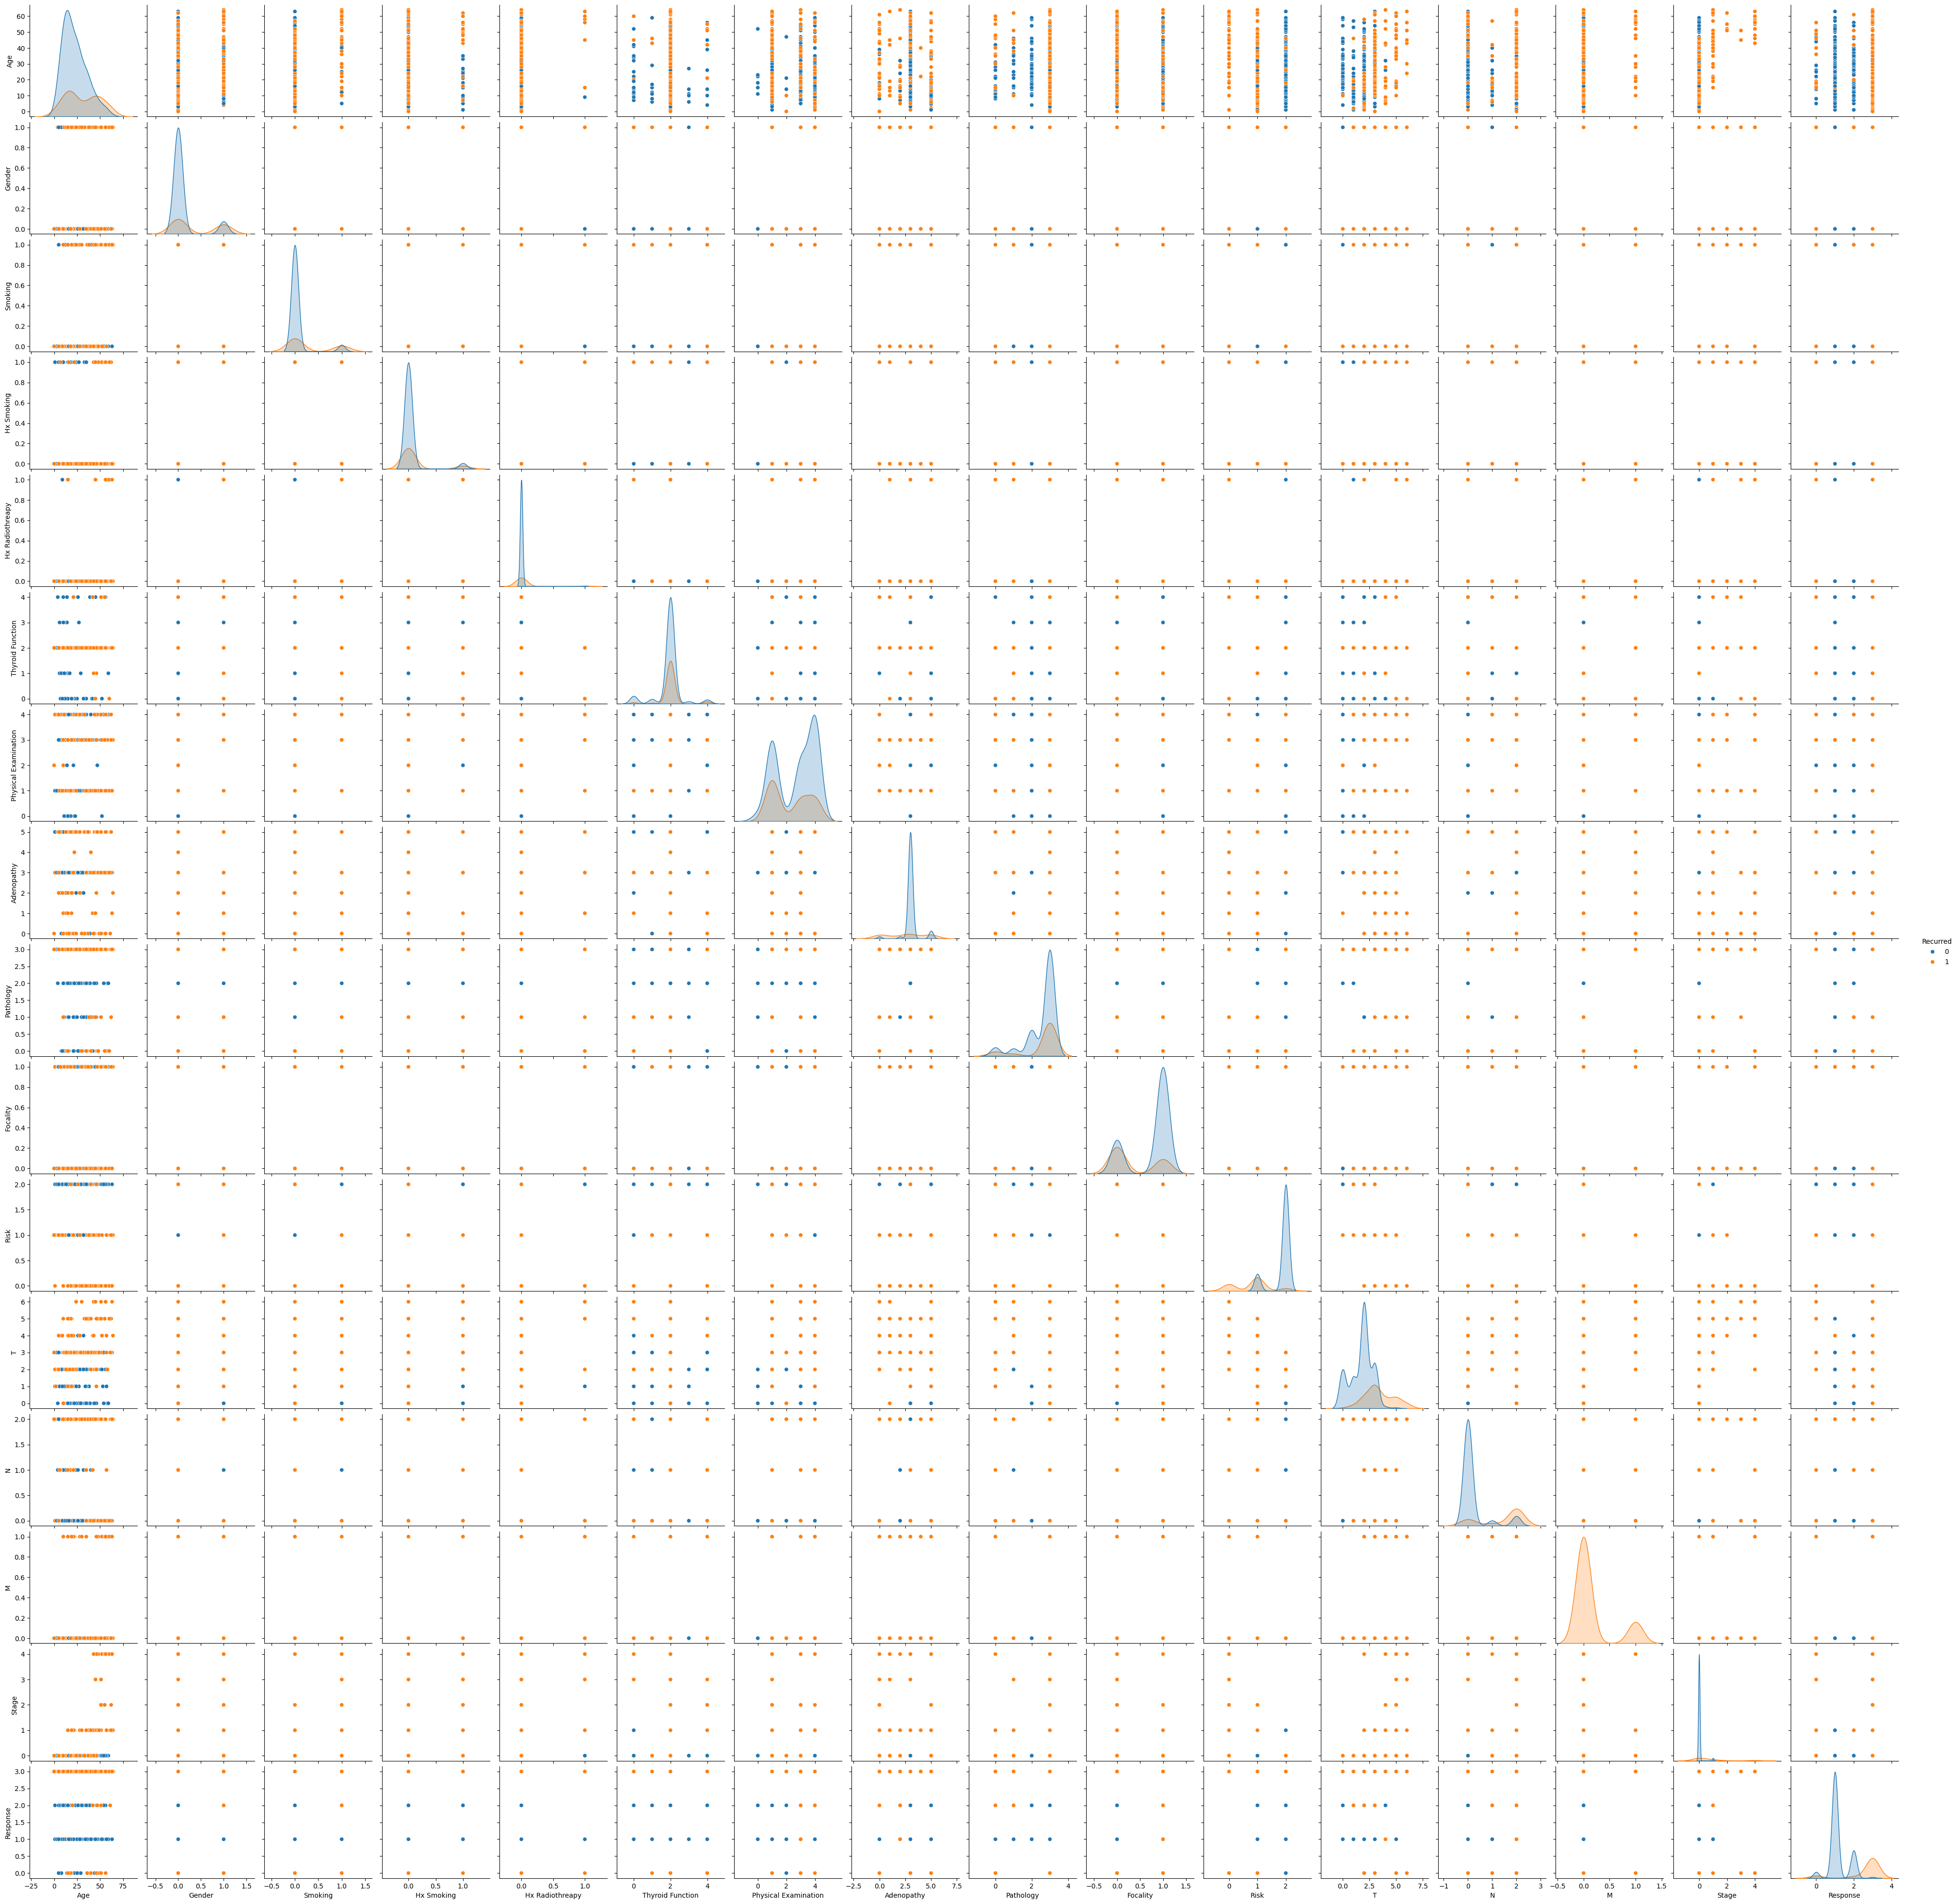

In [26]:
sns.pairplot(df, hue='Recurred')
plt.show()

In [27]:
X = df.drop(columns=['Recurred'])
y = df['Recurred']
f_scores, p_values = f_regression(X, y)
feature_scores_df = pd.DataFrame({'Feature': X.columns, 'F_Score': f_scores,'P_Value': p_values})
feature_scores_df = feature_scores_df.sort_values(by='F_Score', ascending=False)
feature_scores_df

,Feature,F_Score,P_Value
10,Risk,443.390121,7.723436e-66
15,Response,385.013106,9.520716e-60
12,N,253.823287,3.710287e-44
11,T,170.661941,1.741654e-32
14,Stage,96.278731,2.063300e-20
9,Focality,65.807733,6.902362e-15
13,M,54.712794,8.968689e-13
2,Smoking,47.595845,2.192081e-11
1,Gender,45.990326,4.546791e-11
0,Age,27.092469,3.177935e-07


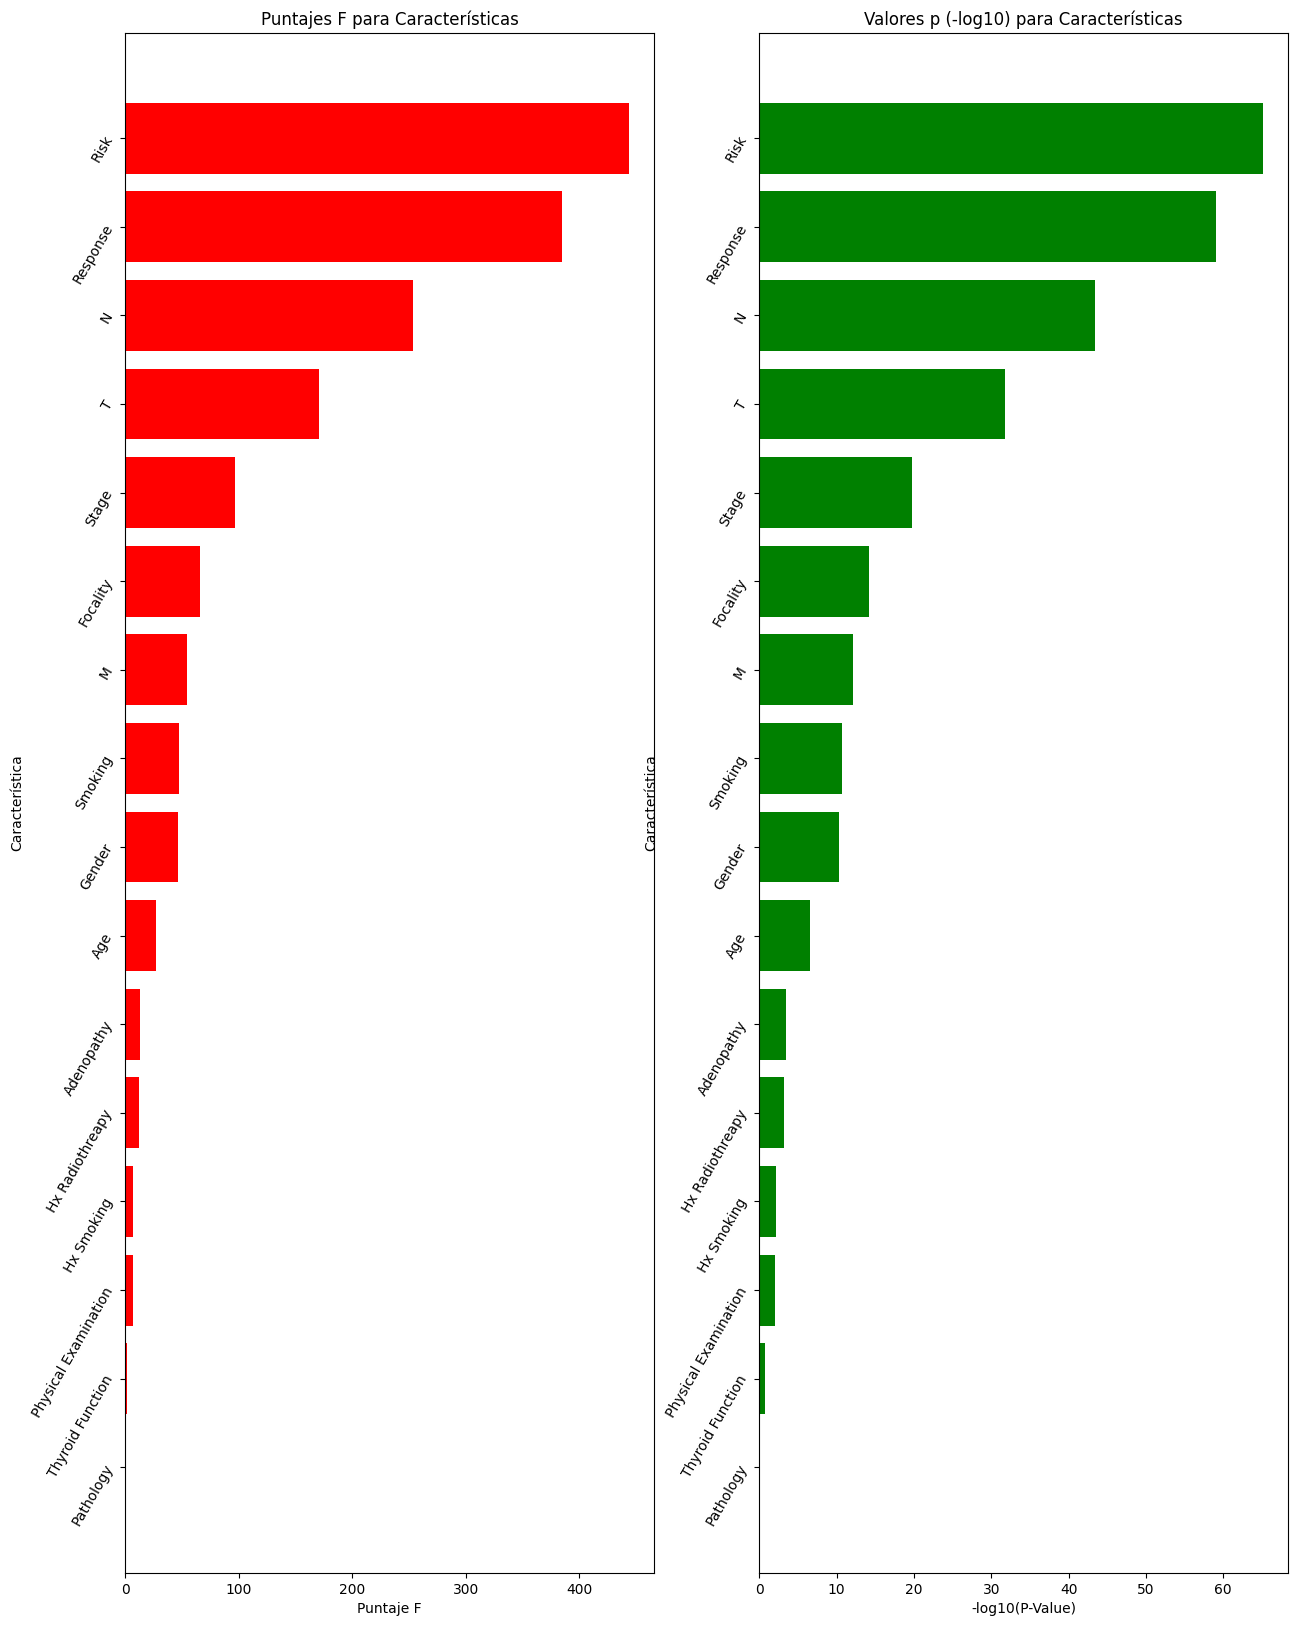

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(15, 20))
ax[0].barh(feature_scores_df['Feature'], feature_scores_df['F_Score'],color='red')
ax[0].set_xlabel('Puntaje F')
ax[0].set_ylabel('Característica')
ax[0].set_title('Puntajes F para Características')

ax[1].barh(feature_scores_df['Feature'], -np.log10(feature_scores_df['P_Value']), color='green')
ax[1].set_xlabel('-log10(P-Value)')
ax[1].set_ylabel('Característica')
ax[1].set_title('Valores p (-log10) para Características')
ax[0].tick_params(axis='y', labelrotation=60)
ax[1].tick_params(axis='y', labelrotation=60)
ax[0].invert_yaxis()
ax[1].invert_yaxis()
plt.show()

In [29]:
cols = feature_scores_df[feature_scores_df['F_Score']>=47].Feature.to_list()
cols

['Risk', 'Response', 'N', 'T', 'Stage', 'Focality', 'M', 'Smoking']

In [30]:
X_M = df[cols]
Y_M = df['Recurred']
scaler = StandardScaler()
x = scaler.fit_transform(X_M)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(x, Y_M, test_size=0.25,random_state=42)

In [32]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)
logistic_model.score(X_train, y_train)
model_pred_L = logistic_model.predict(X_test)
print(classification_report(y_test, model_pred_L))
print("accuracy: ",accuracy_score(y_test, model_pred_L))
print("mean_absolute_error: ",mean_absolute_error(y_test, model_pred_L))
print("mean_squared_error: ",mean_squared_error(y_test, model_pred_L))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        68
           1       0.96      0.82      0.88        28

    accuracy                           0.94        96
   macro avg       0.94      0.90      0.92        96
weighted avg       0.94      0.94      0.94        96

accuracy:  0.9375
mean_absolute_error:  0.0625
mean_squared_error:  0.0625


In [33]:
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)
random_forest_model.score(X_train, y_train)
model_pred_R = random_forest_model.predict(X_test)
print(classification_report(y_test, model_pred_R))
print("accuracy: ",accuracy_score(y_test, model_pred_R))
print("mean_absolute_error: ",mean_absolute_error(y_test, model_pred_R))
print("mean_squared_error: ",mean_squared_error(y_test, model_pred_R))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        68
           1       0.96      0.96      0.96        28

    accuracy                           0.98        96
   macro avg       0.97      0.97      0.97        96
weighted avg       0.98      0.98      0.98        96

accuracy:  0.9791666666666666
mean_absolute_error:  0.020833333333333332
mean_squared_error:  0.020833333333333332


In [34]:
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
decision_tree_model.score(X_train, y_train)
model_pred_T = decision_tree_model.predict(X_test)
print(classification_report(y_test, model_pred_T))
print("accuracy: ",accuracy_score(y_test, model_pred_T))
print("mean_absolute_error: ",mean_absolute_error(y_test, model_pred_T))
print("mean_squared_error: ",mean_squared_error(y_test, model_pred_T))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96        68
           1       0.90      0.93      0.91        28

    accuracy                           0.95        96
   macro avg       0.93      0.94      0.94        96
weighted avg       0.95      0.95      0.95        96

accuracy:  0.9479166666666666
mean_absolute_error:  0.052083333333333336
mean_squared_error:  0.052083333333333336


In [35]:
model_SVC = SVC(kernel = 'rbf' ,random_state = 42)
model_SVC.fit(X_train, y_train)
model_SVC.score(X_train, y_train)
model_SVC_Pred = model_SVC.predict(X_test)
print(classification_report(y_test, model_SVC_Pred))
print("accuracy: ",accuracy_score(y_test, model_SVC_Pred))
print("mean_absolute_error: ",mean_absolute_error(y_test, model_SVC_Pred))
print("mean_squared_error: ",mean_squared_error(y_test, model_SVC_Pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        68
           1       1.00      0.86      0.92        28

    accuracy                           0.96        96
   macro avg       0.97      0.93      0.95        96
weighted avg       0.96      0.96      0.96        96

accuracy:  0.9583333333333334
mean_absolute_error:  0.041666666666666664
mean_squared_error:  0.041666666666666664


In [36]:
model_NEG = KNeighborsClassifier(n_neighbors=4)
model_NEG.fit(X_train, y_train)
model_NEG.score(X_train, y_train)
model_NEG_Pred = model_NEG.predict(X_test)
print(classification_report(y_test, model_NEG_Pred))
print("accuracy: ",accuracy_score(y_test, model_NEG_Pred))
print("mean_absolute_error: ",mean_absolute_error(y_test, model_NEG_Pred))
print("mean_squared_error: ",mean_squared_error(y_test, model_NEG_Pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        68
           1       1.00      0.79      0.88        28

    accuracy                           0.94        96
   macro avg       0.96      0.89      0.92        96
weighted avg       0.94      0.94      0.94        96

accuracy:  0.9375
mean_absolute_error:  0.0625
mean_squared_error:  0.0625


In [37]:
model_NB = GaussianNB()
model_NB.fit(X_train, y_train)
model_NB_Pred = model_NB.predict(X_test)
print(classification_report(y_test, model_NB_Pred))
print("accuracy: ",accuracy_score(y_test, model_NB_Pred))
print("mean_absolute_error: ",mean_absolute_error(y_test, model_NB_Pred))
print("mean_squared_error: ",mean_squared_error(y_test, model_NB_Pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        68
           1       1.00      0.50      0.67        28

    accuracy                           0.85        96
   macro avg       0.91      0.75      0.79        96
weighted avg       0.88      0.85      0.84        96

accuracy:  0.8541666666666666
mean_absolute_error:  0.14583333333333334
mean_squared_error:  0.14583333333333334


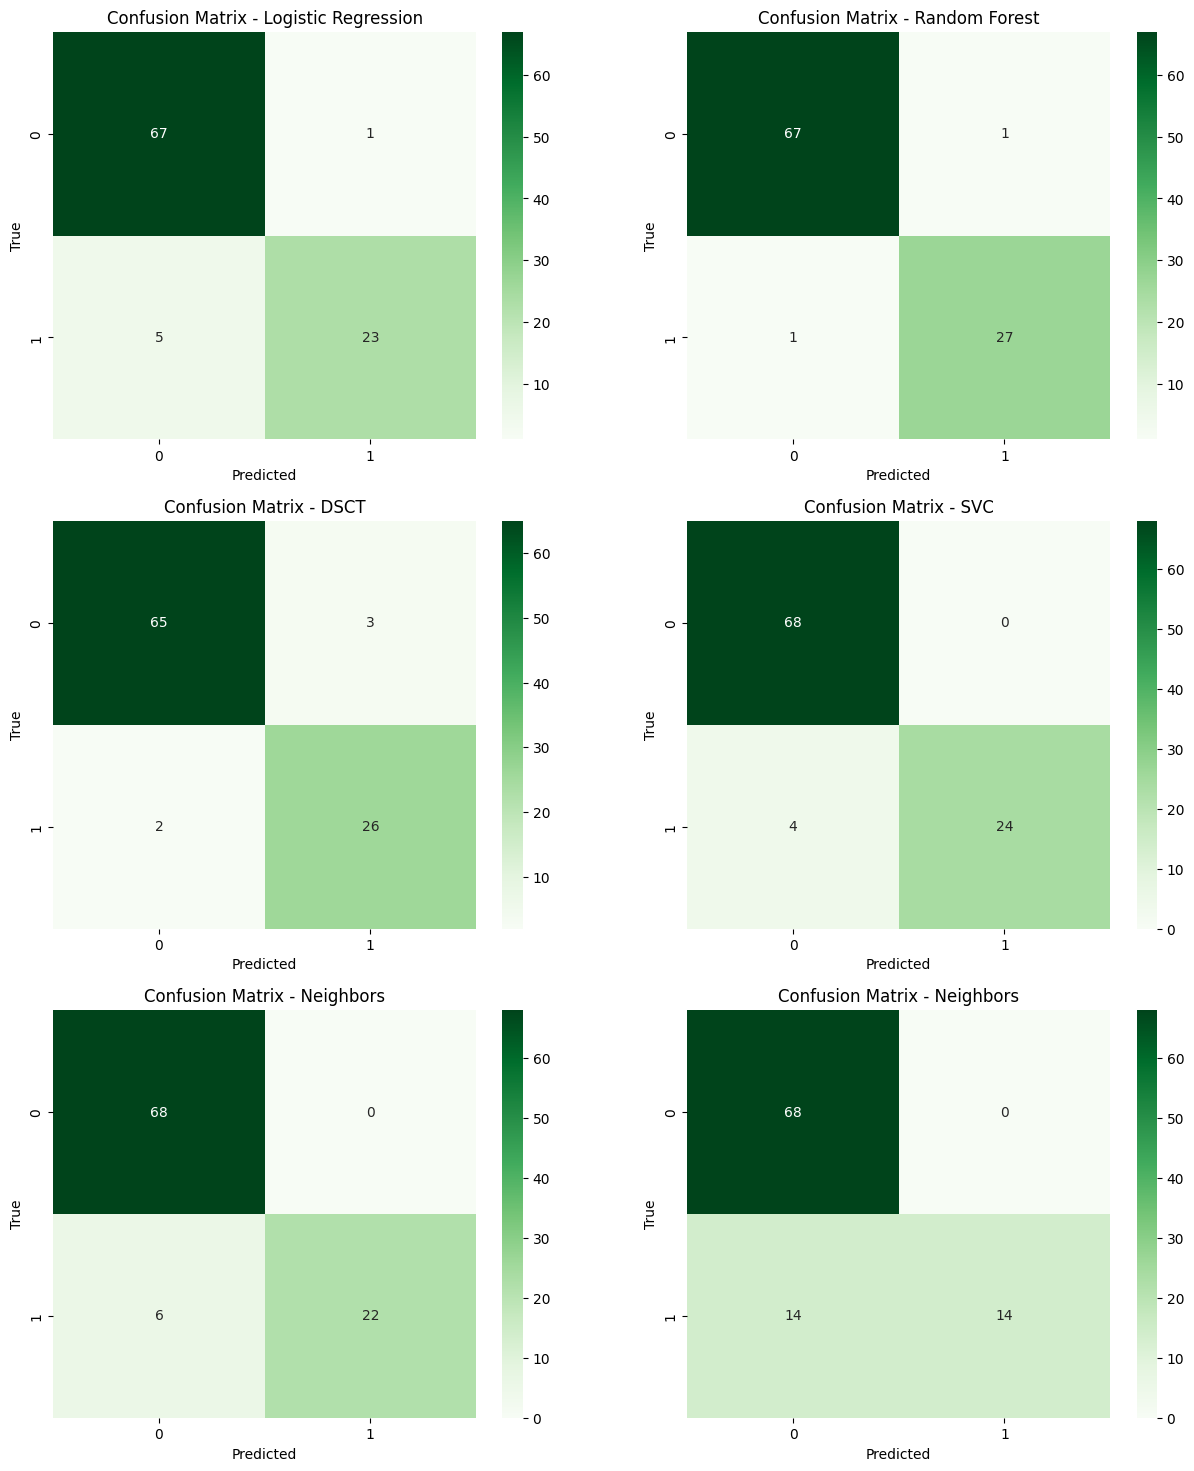

In [38]:
RLOG = confusion_matrix(y_test, model_pred_L)
RMFC = confusion_matrix(y_test, model_pred_R)
DSCT = confusion_matrix(y_test, model_pred_T)
SVC_ = confusion_matrix(y_test, model_SVC_Pred)
NEG = confusion_matrix(y_test, model_NEG_Pred)
NB = confusion_matrix(y_test, model_NB_Pred)
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
sns.heatmap(RLOG, annot=True, cmap='Greens', fmt='g', ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix - Logistic Regression')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('True')
sns.heatmap(RMFC, annot=True, cmap='Greens', fmt='g', ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix - Random Forest')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('True')
sns.heatmap(DSCT, annot=True, cmap='Greens', fmt='g', ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix - DSCT')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('True')
sns.heatmap(SVC_, annot=True, cmap='Greens', fmt='g', ax=axes[1,1])
axes[1,1].set_title('Confusion Matrix - SVC')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('True')
sns.heatmap(NEG, annot=True, cmap='Greens', fmt='g', ax=axes[2,0])
axes[2,0].set_title('Confusion Matrix - Neighbors')
axes[2,0].set_xlabel('Predicted')
axes[2,0].set_ylabel('True')
sns.heatmap(NB, annot=True, cmap='Greens', fmt='g', ax=axes[2,1])
axes[2,1].set_title('Confusion Matrix - Neighbors')
axes[2,1].set_xlabel('Predicted')
axes[2,1].set_ylabel('True')
plt.show()

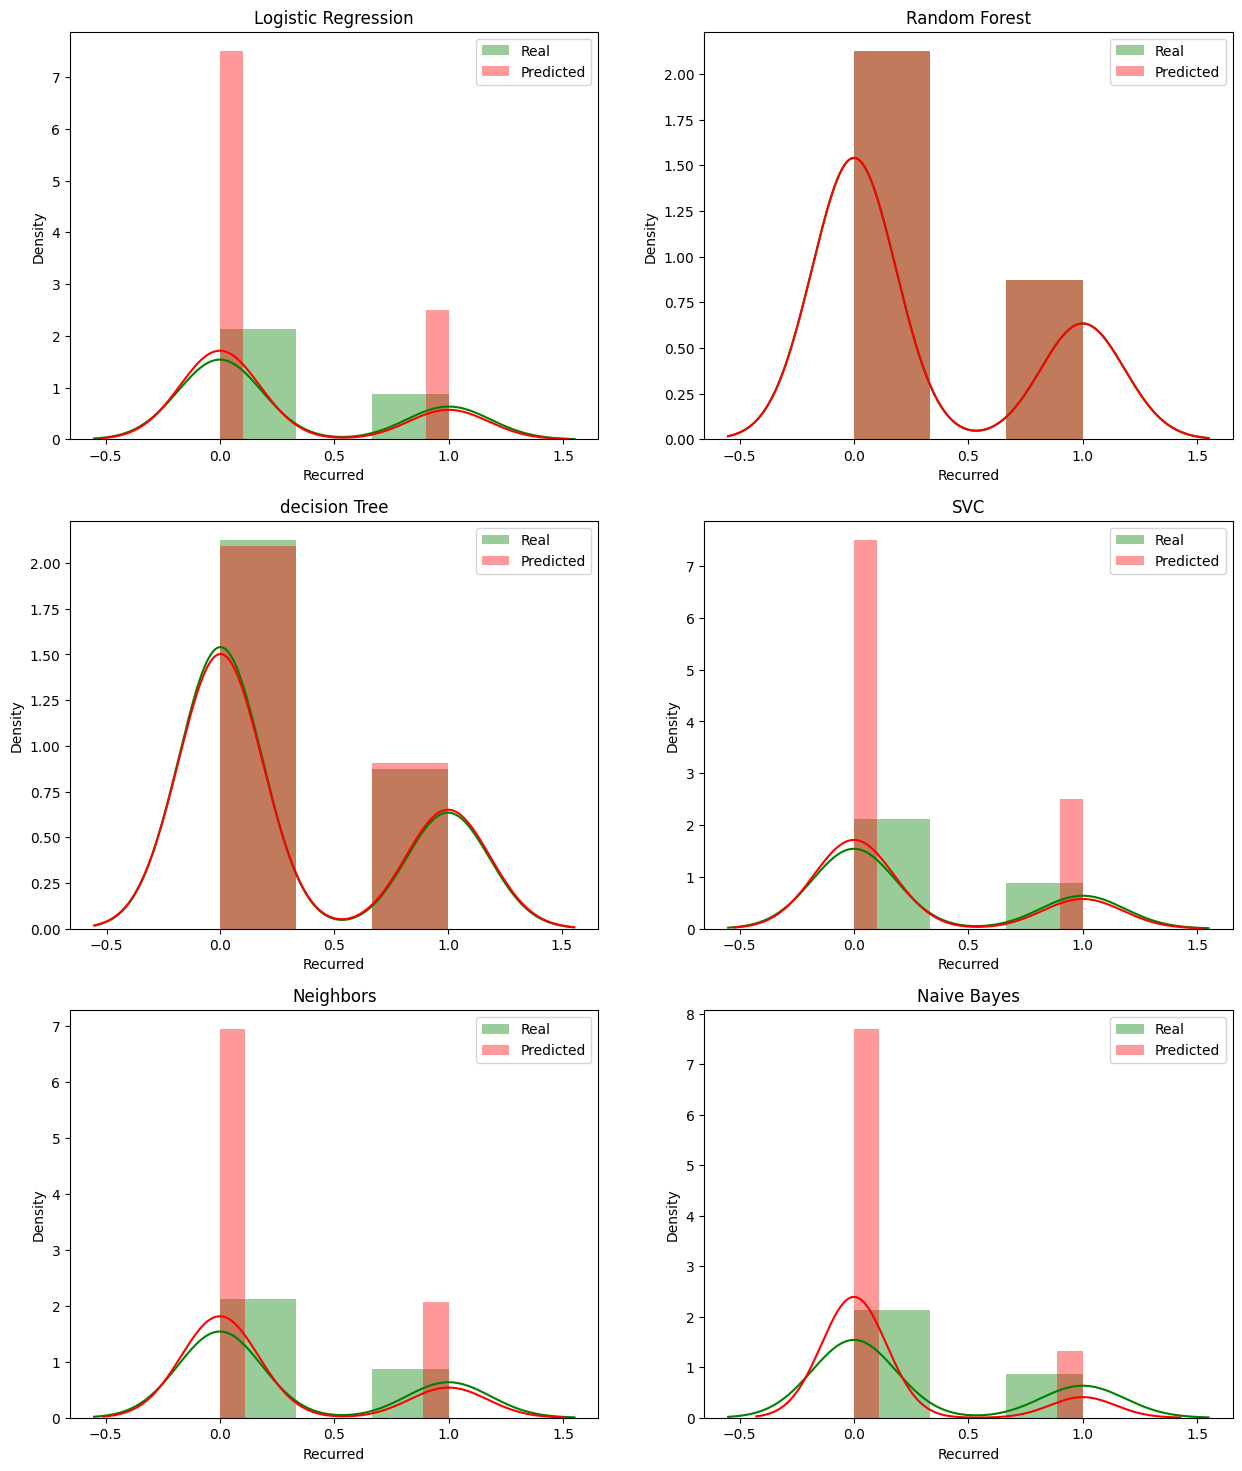

In [39]:
fig, ax = plt.subplots(3, 2, figsize=(15, 18))
sns.distplot(y_test, label='Real', ax=ax[0,0], color = 'Green')
sns.distplot(model_pred_L, label='Predicted', ax=ax[0,0], color = 'red')
sns.distplot(y_test, label='Real', ax=ax[0,1], color = 'Green')
sns.distplot(model_pred_R, label='Predicted', ax=ax[0,1], color = 'red')
sns.distplot(y_test, label='Real', ax=ax[1,0], color = 'Green')
sns.distplot(model_pred_T, label='Predicted', ax=ax[1,0], color = 'red')
sns.distplot(y_test, label='Real', ax=ax[1,1], color = 'Green')
sns.distplot(model_SVC_Pred, label='Predicted', ax=ax[1,1], color = 'red')
sns.distplot(y_test, label='Real', ax=ax[2,0], color = 'Green')
sns.distplot(model_NEG_Pred, label='Predicted', ax=ax[2,0], color = 'red')
sns.distplot(y_test, label='Real', ax=ax[2,1], color = 'Green')
sns.distplot(model_NB_Pred, label='Predicted', ax=ax[2,1], color = 'red')

ax[0,0].set_title('Logistic Regression')
ax[0,1].set_title('Random Forest')
ax[1,0].set_title('decision Tree')
ax[1,1].set_title('SVC')
ax[2,0].set_title('Neighbors')
ax[2,1].set_title('Naive Bayes')
ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()
ax[2,0].legend()
ax[2,1].legend()
plt.show()

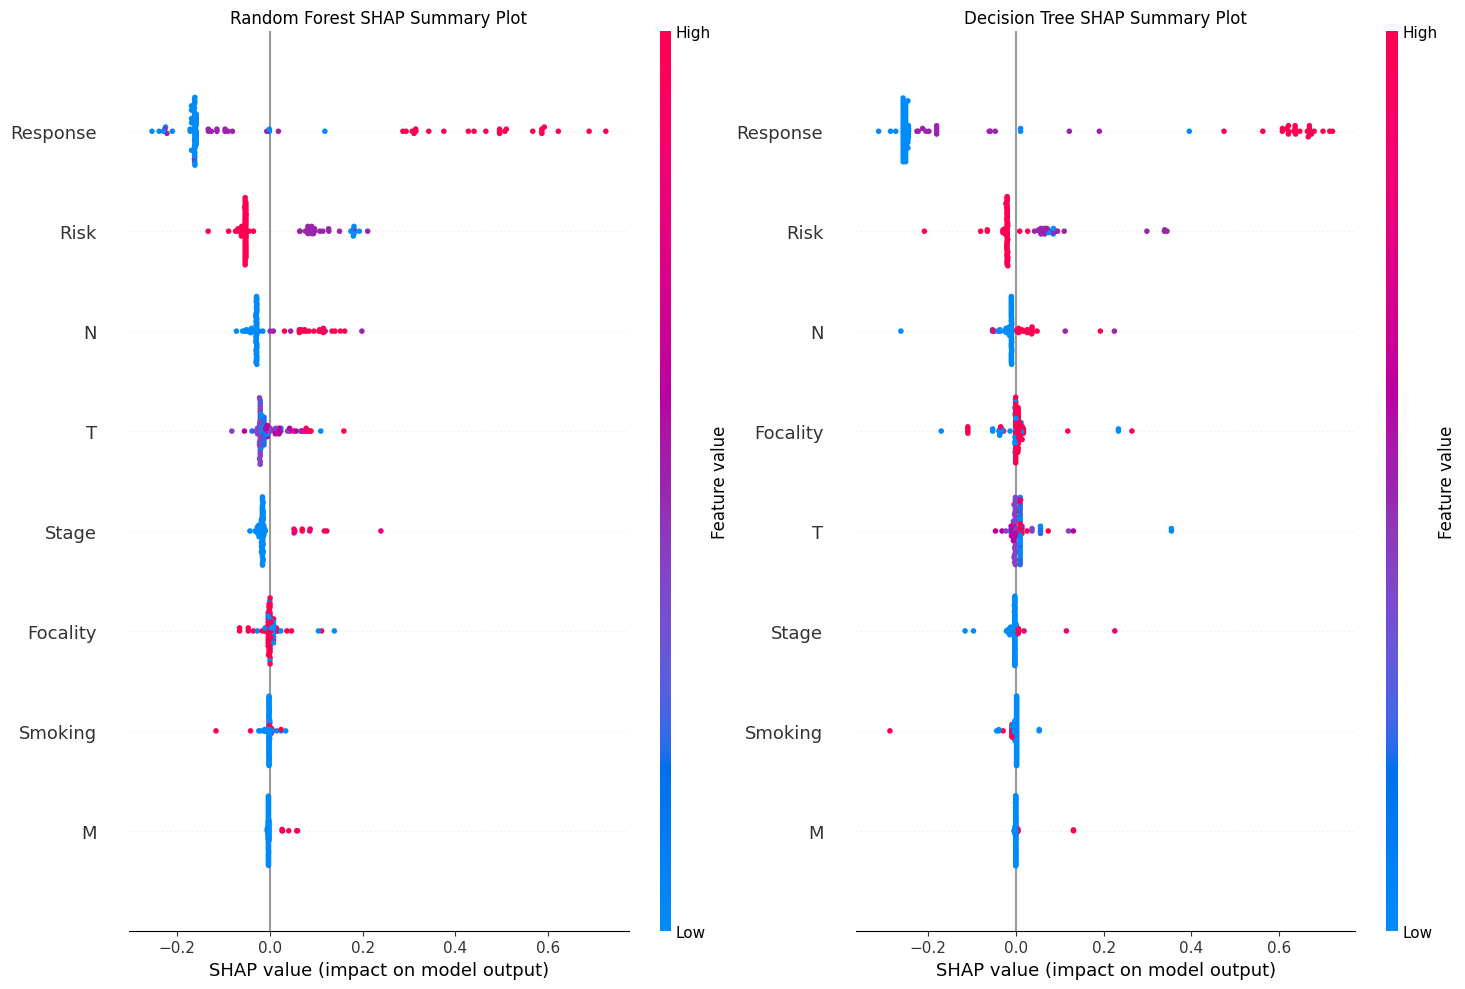

In [52]:
X_test_df=pd.DataFrame(X_test,columns=X_M.columns)
explainer_random_forest = shap.TreeExplainer(random_forest_model)
explainer_decision_tree_ = shap.TreeExplainer(decision_tree_model)
shap_values_r = explainer_random_forest.shap_values(X_test_df)
shap_values_d = explainer_decision_tree_.shap_values(X_test_df)
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values_r[:, :, 1], X_test_df, feature_names=X_M.columns,plot_size=(15, 10), show=False)
plt.title("Random Forest SHAP Summary Plot")

plt.subplot(1, 2, 2)
shap.summary_plot(shap_values_d[:, :, 1], X_test_df, feature_names=X_M.columns,plot_size=(15, 10), show=False)
plt.title("Decision Tree SHAP Summary Plot")
plt.show()

In [53]:
import gradio as gr
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
explainer = shap.TreeExplainer(random_forest_model)
top_features = ['Risk', 'Response', 'N', 'T', 'Stage', 'Focality', 'M', 'Smoking']

def predict_and_explain(*args):
    input_df = pd.DataFrame([args], columns=top_features)
    for col in input_df.columns:
        if input_df[col].dtype == 'object':
            input_df[col] = label_encoder.transform(input_df[col])

    input_scaled = scaler.transform(input_df)

    pred = random_forest_model.predict(input_scaled)[0]
    prob = random_forest_model.predict_proba(input_scaled)[0]

    result_text = "⚠️ High Risk of Recurrence" if pred == 1 else "✅ Low Risk of Recurrence"
    confidence = f"Confidence: {max(prob) * 100:.2f}%"

    shap_values_single = explainer(input_scaled)

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_values_single[0][:, 1], max_display=8, show=False)
    plt.tight_layout()

    plot_path = "shap_explanation.png"
    plt.savefig(plot_path)
    plt.close()

    return f"{result_text}\n{confidence}", plot_path

with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🦋 Explainable Thyroid Cancer Recurrence Predictor")
    gr.Markdown("Based on the top 8 predictive features. The chart below will explain exactly how each clinical factor pushed the model toward or away from a recurrence prediction.")

    with gr.Row():
        with gr.Column():
            risk = gr.Dropdown(choices=['Low', 'Intermediate', 'High'], label="Risk Category")
            response = gr.Dropdown(choices=['Excellent', 'Structural Incomplete', 'Indeterminate', 'Biochemical Incomplete'], label="Initial Treatment Response")
            n_stage = gr.Dropdown(choices=['N0', 'N1a', 'N1b'], label="N (Lymph Node Involvement)")
            t_stage = gr.Dropdown(choices=['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'], label="T (Tumor Size/Extent)")

        with gr.Column():
            stage = gr.Dropdown(choices=['I', 'II', 'III', 'IVA', 'IVB'], label="Clinical Stage")
            focality = gr.Dropdown(choices=['Uni-Focal', 'Multi-Focal'], label="Focality")
            m_stage = gr.Dropdown(choices=['M0', 'M1'], label="M (Metastasis)")
            smoking = gr.Dropdown(choices=['No', 'Yes'], label="Smoking History")

    btn = gr.Button("Predict & Explain")

    with gr.Row():
        text_output = gr.Textbox(label="Prediction", lines=2)
        image_output = gr.Image(label="SHAP Feature Impact Analysis")

    btn.click(
        fn=predict_and_explain,
        inputs=[risk, response, n_stage, t_stage, stage, focality, m_stage, smoking],
        outputs=[text_output, image_output]
    )

app.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4a6acec8f51e7dd277.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_encode.py", line 235, in _encode
    return _map_to_integer(values, uniques)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_encode.py", line 174, in _map_to_integer
    return xp.asarray([table[v] for v in values], device=device(values))
                       ~~~~~^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_encode.py", line 167, in __missing__
    raise KeyError(key)
KeyError: 'Low'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://4a6acec8f51e7dd277.gradio.live
